---

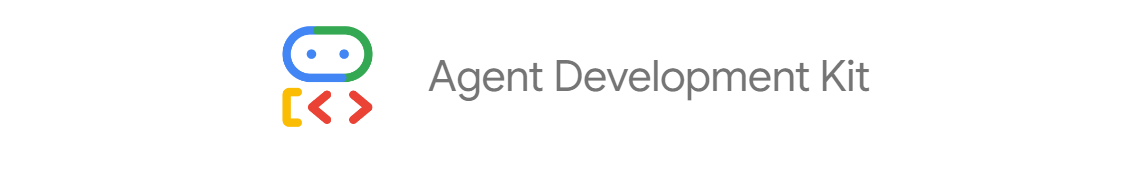

---

# Running Agents  👉 [Click Here](https://google.github.io/adk-docs/runtime/)

---
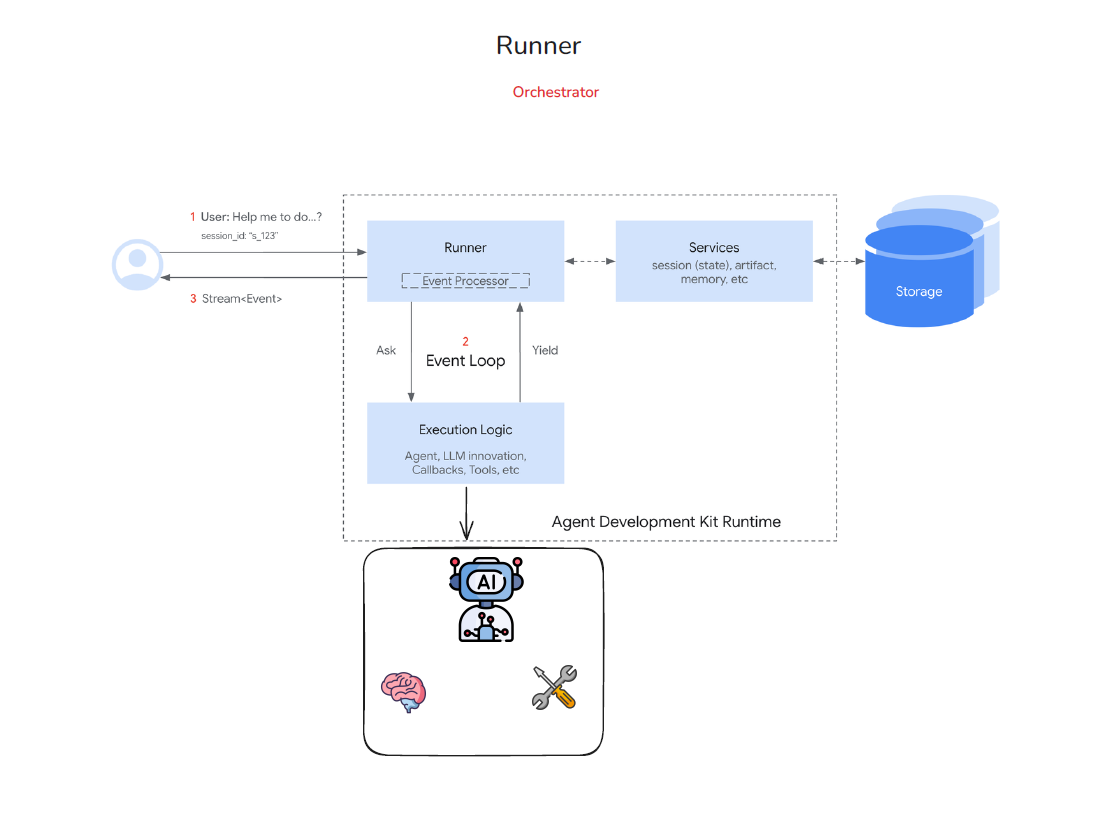

---

## Runtime
**What is runtime?**<br>
The ADK Runtime is the underlying engine that powers your agent application during user interactions. It's the system that takes your defined agents, tools, and callbacks and orchestrates their execution in response to user input, managing the flow of information, state changes, and interactions with external services like LLMs or storage. <br><br>
Think of the Runtime as the "**engine**" of your agentic application. You define the parts (agents, tools), and the Runtime handles how they connect and run together to fulfill a user's request. <br><br>

**Core Idea: The Event Loop**<br>
At its heart, the ADK Runtime operates on an **Event Loop**. This loop facilitates a back-and-forth communication between the Runner component and your defined "Execution Logic" (which includes your Agents, the LLM calls they make, Callbacks, and Tools).
<br><br>

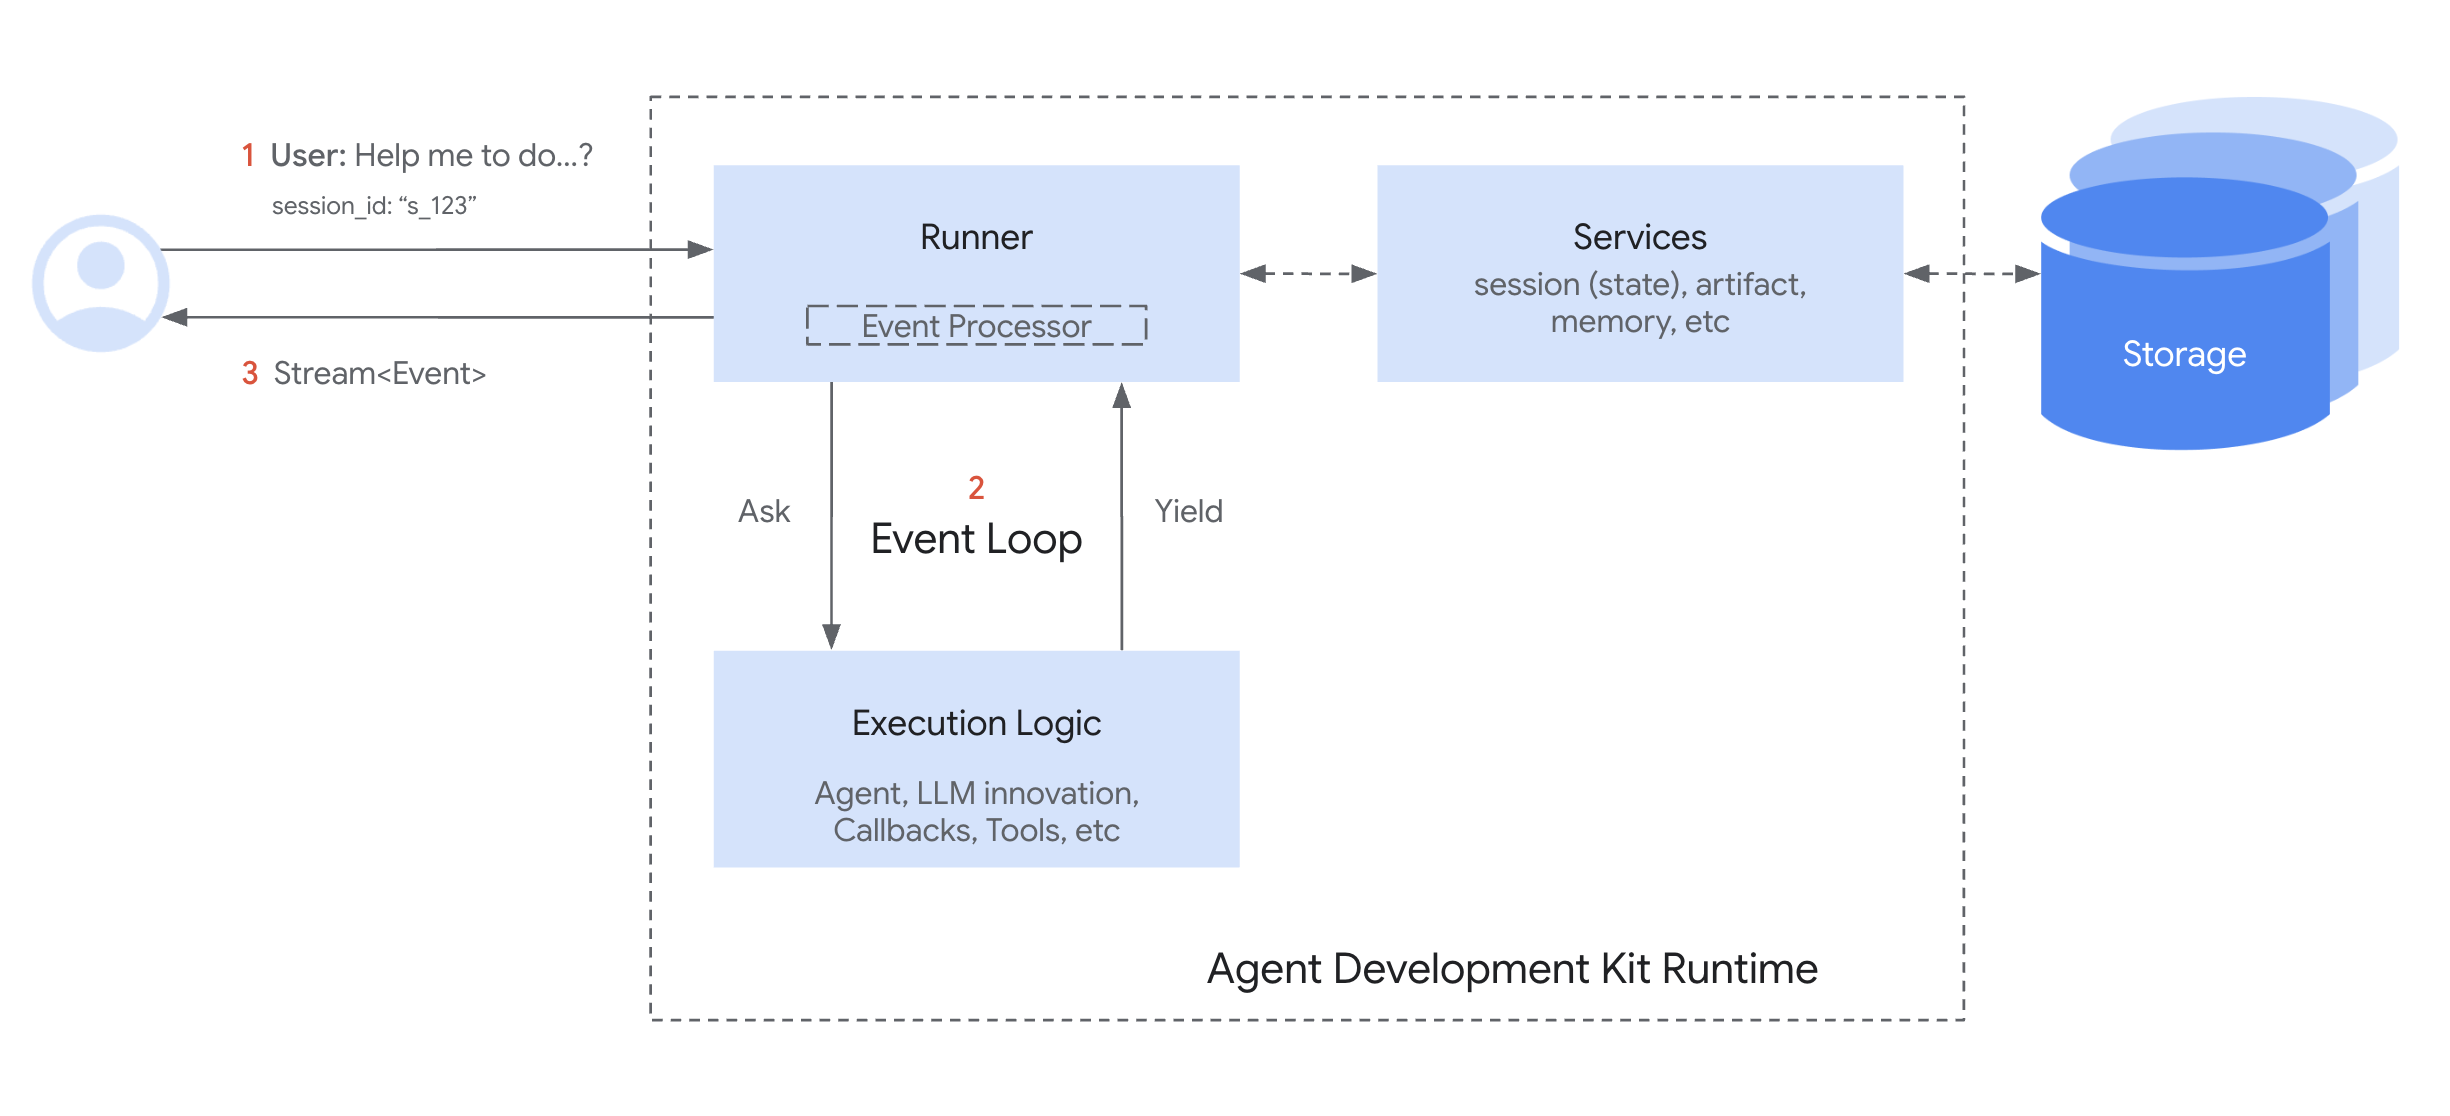 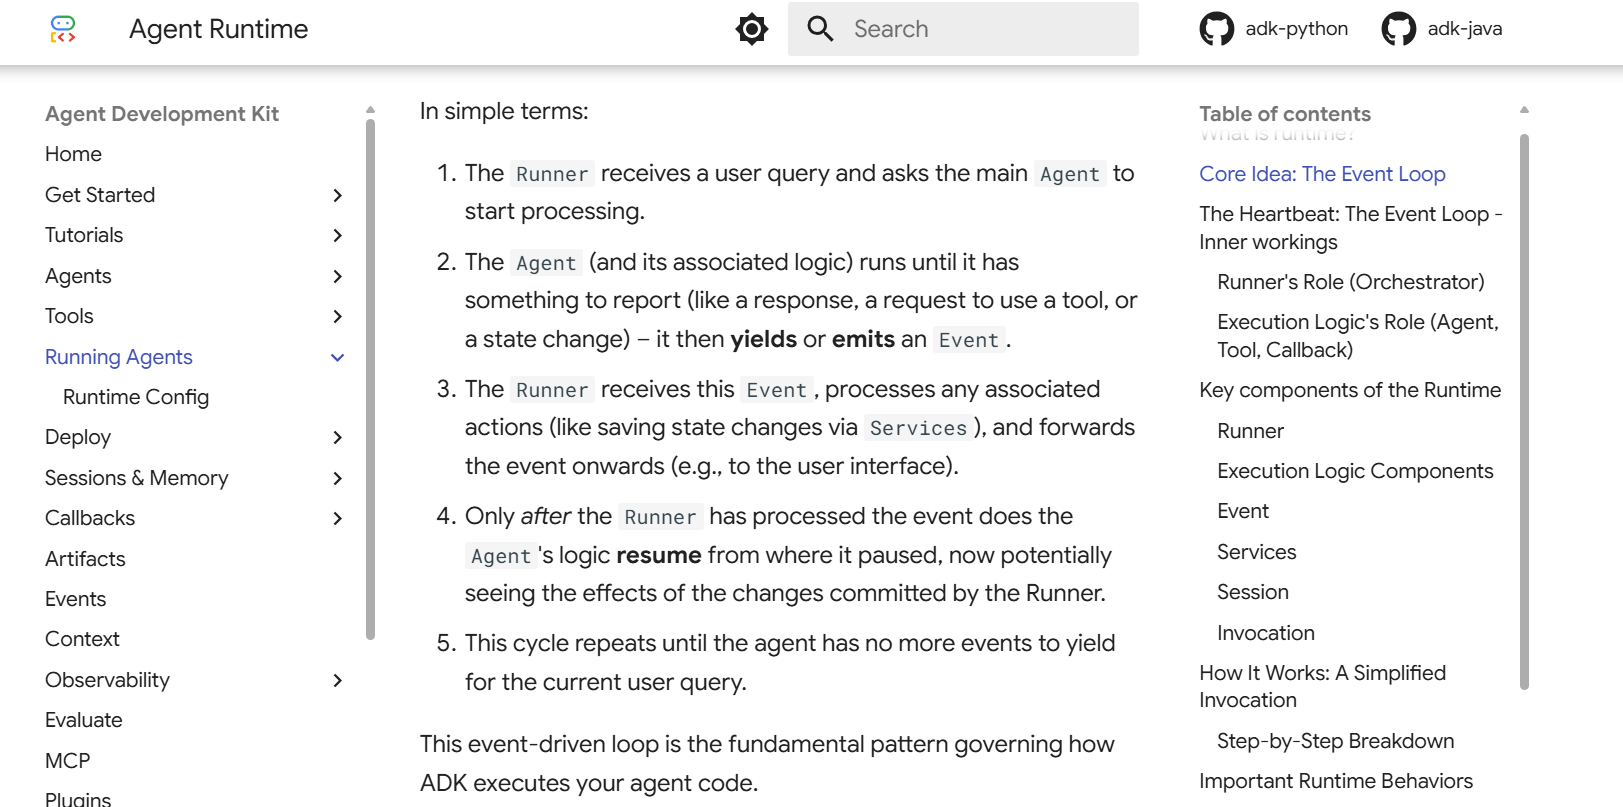 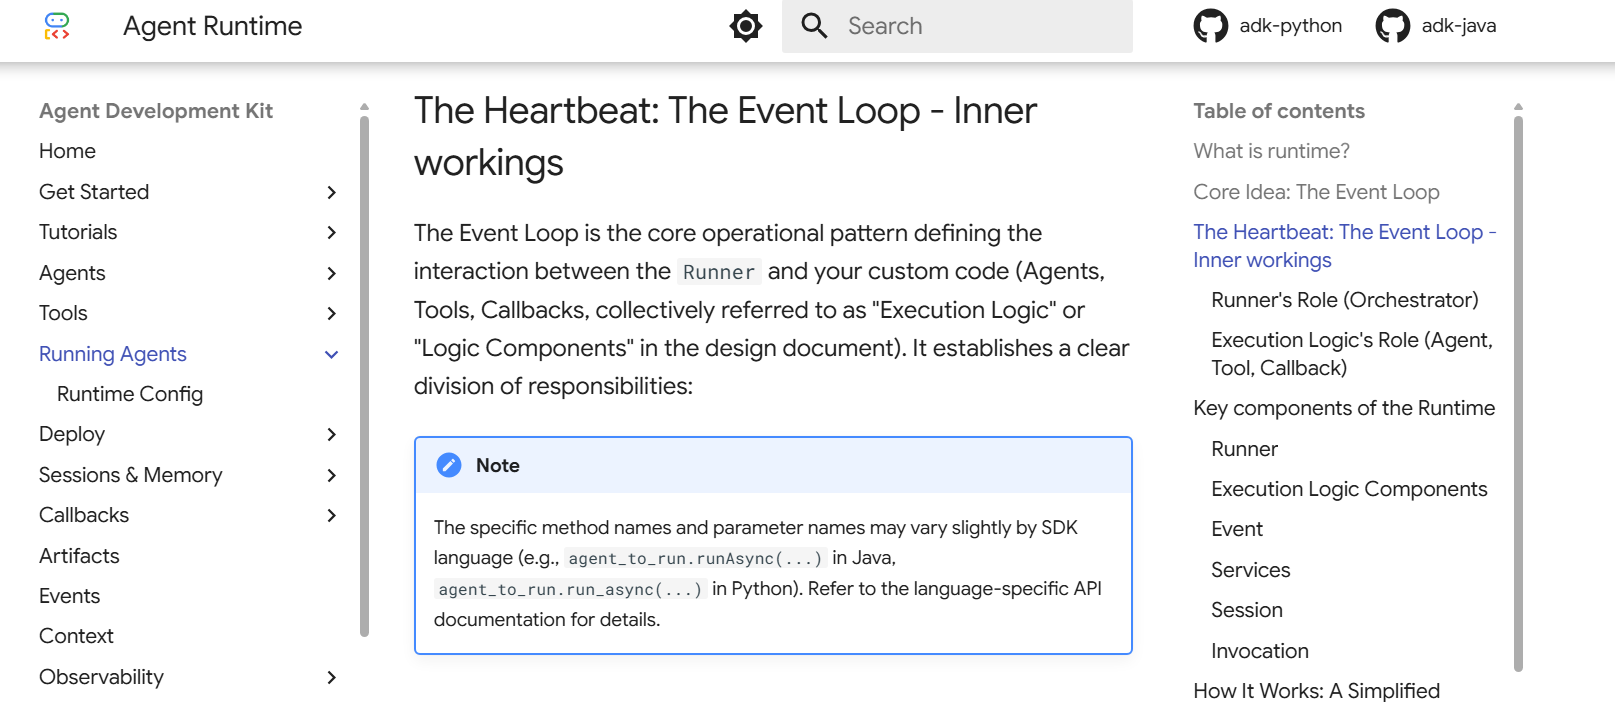
<br><br>

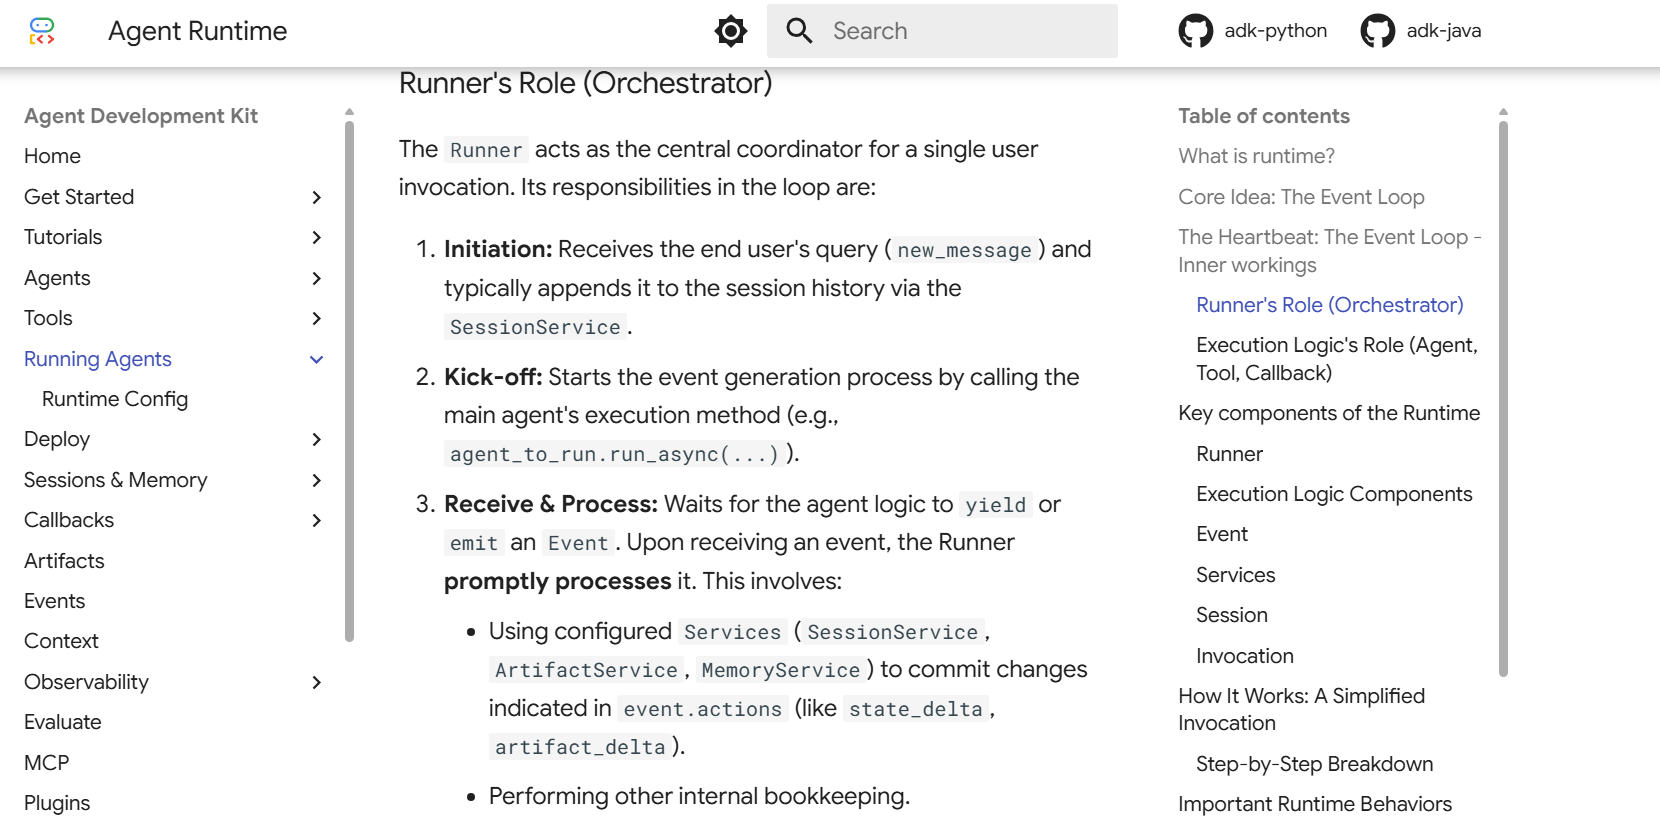 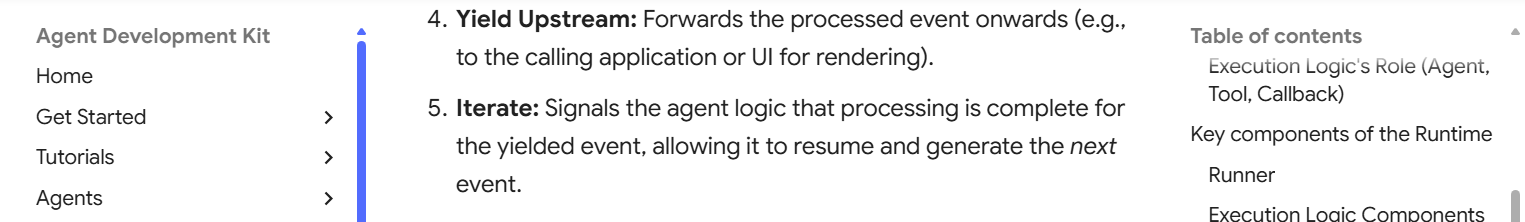

> Conceptual Runner Loop:
```Python
# Simplified view of Runner's main loop logic
def run(new_query, ...) -> Generator[Event]:
    # 1. Append new_query to session event history (via SessionService)
    session_service.append_event(session, Event(author='user', content=new_query))

    # 2. Kick off event loop by calling the agent
    agent_event_generator = agent_to_run.run_async(context)

    async for event in agent_event_generator:
        # 3. Process the generated event and commit changes
        session_service.append_event(session, event) # Commits state/artifact deltas etc.
        # memory_service.update_memory(...) # If applicable
        # artifact_service might have already been called via context during agent run

        # 4. Yield event for upstream processing (e.g., UI rendering)
        yield event
        # Runner implicitly signals agent generator can continue after yielding
```

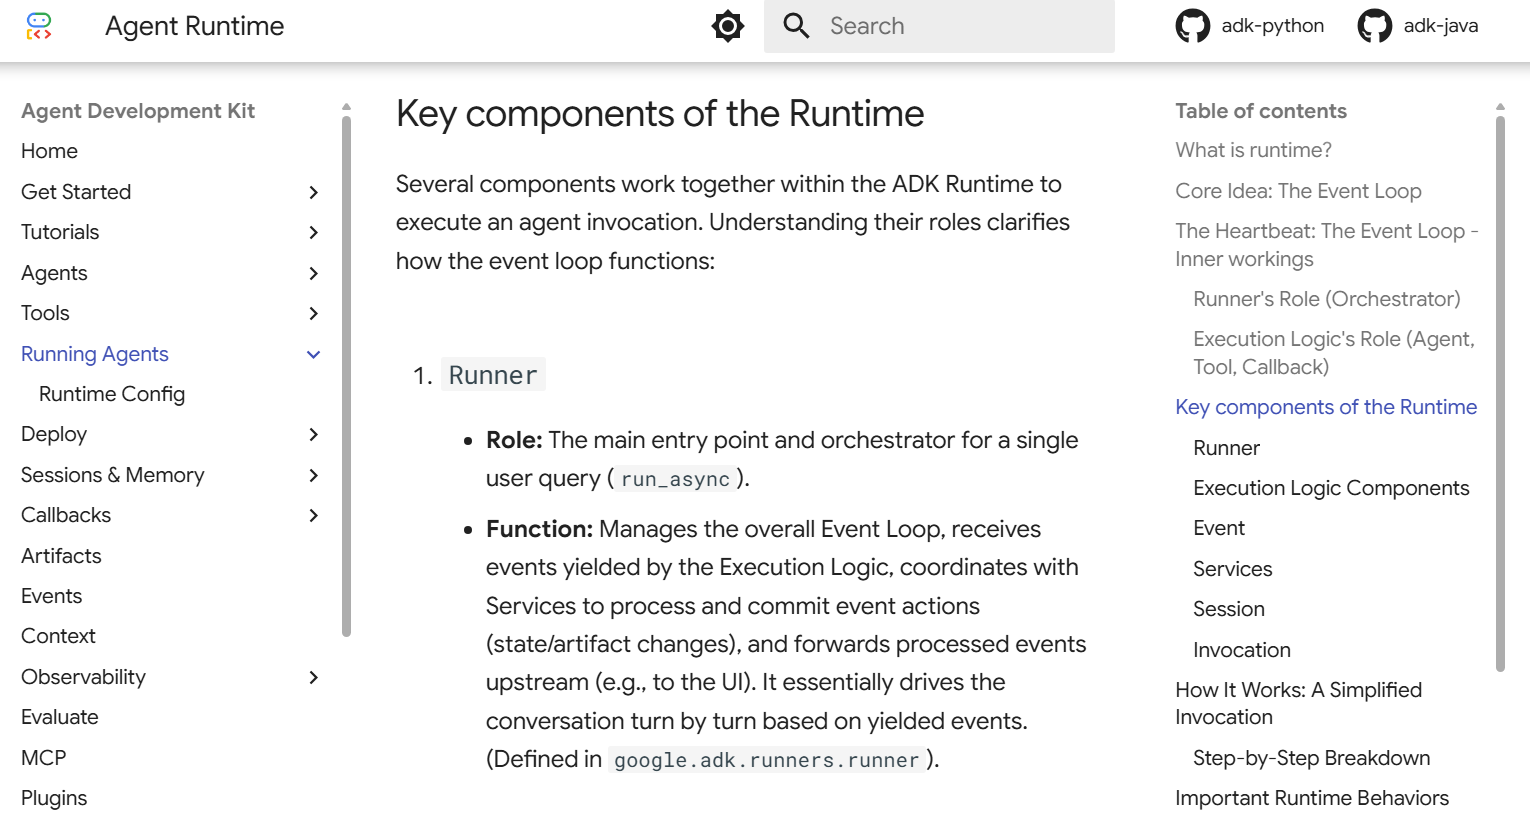 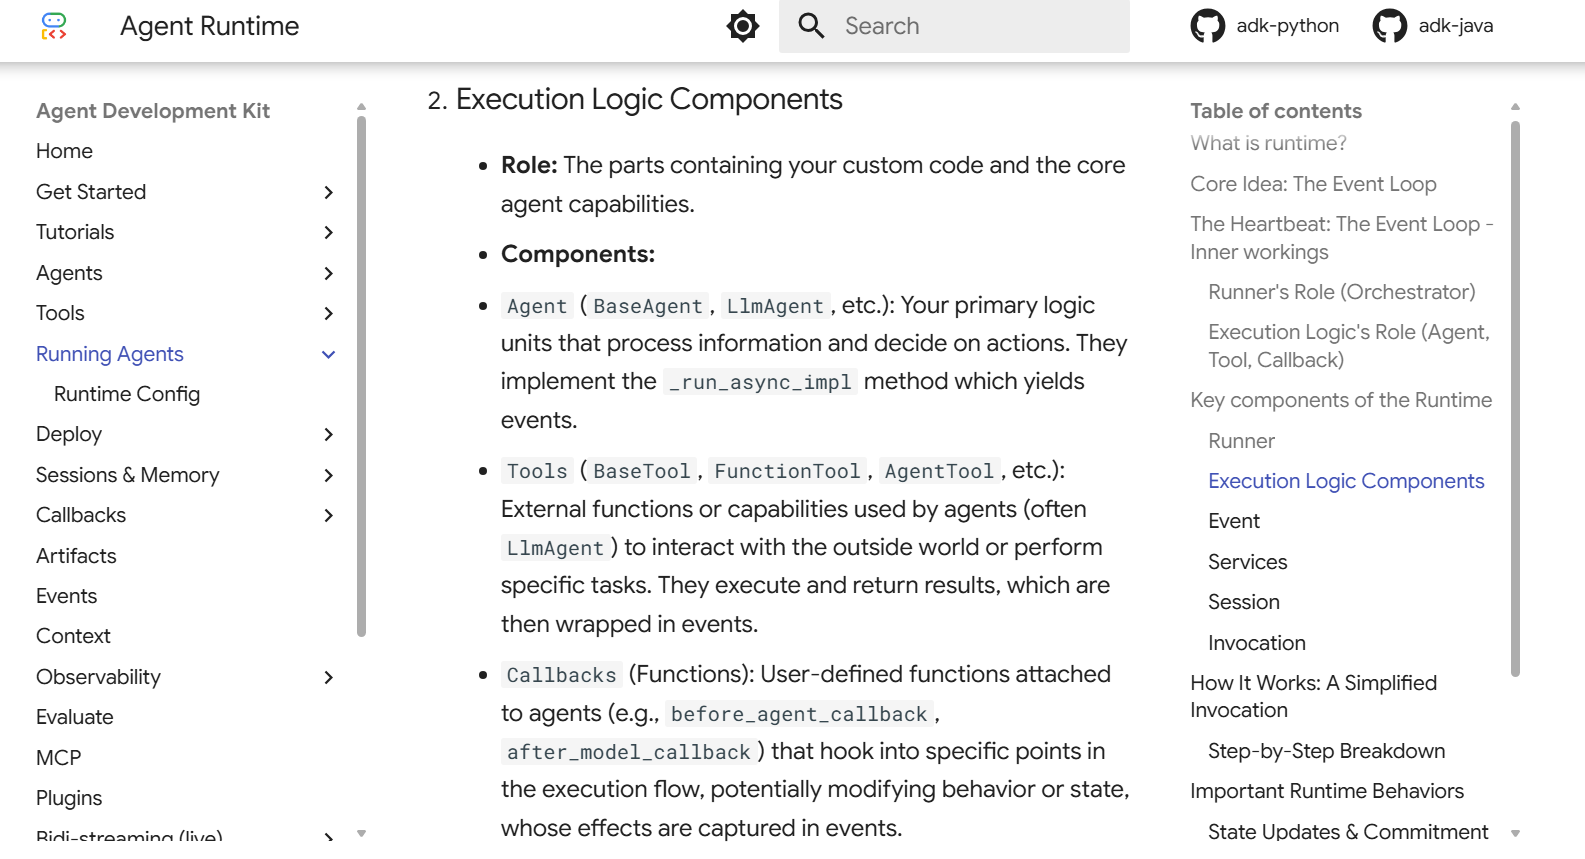 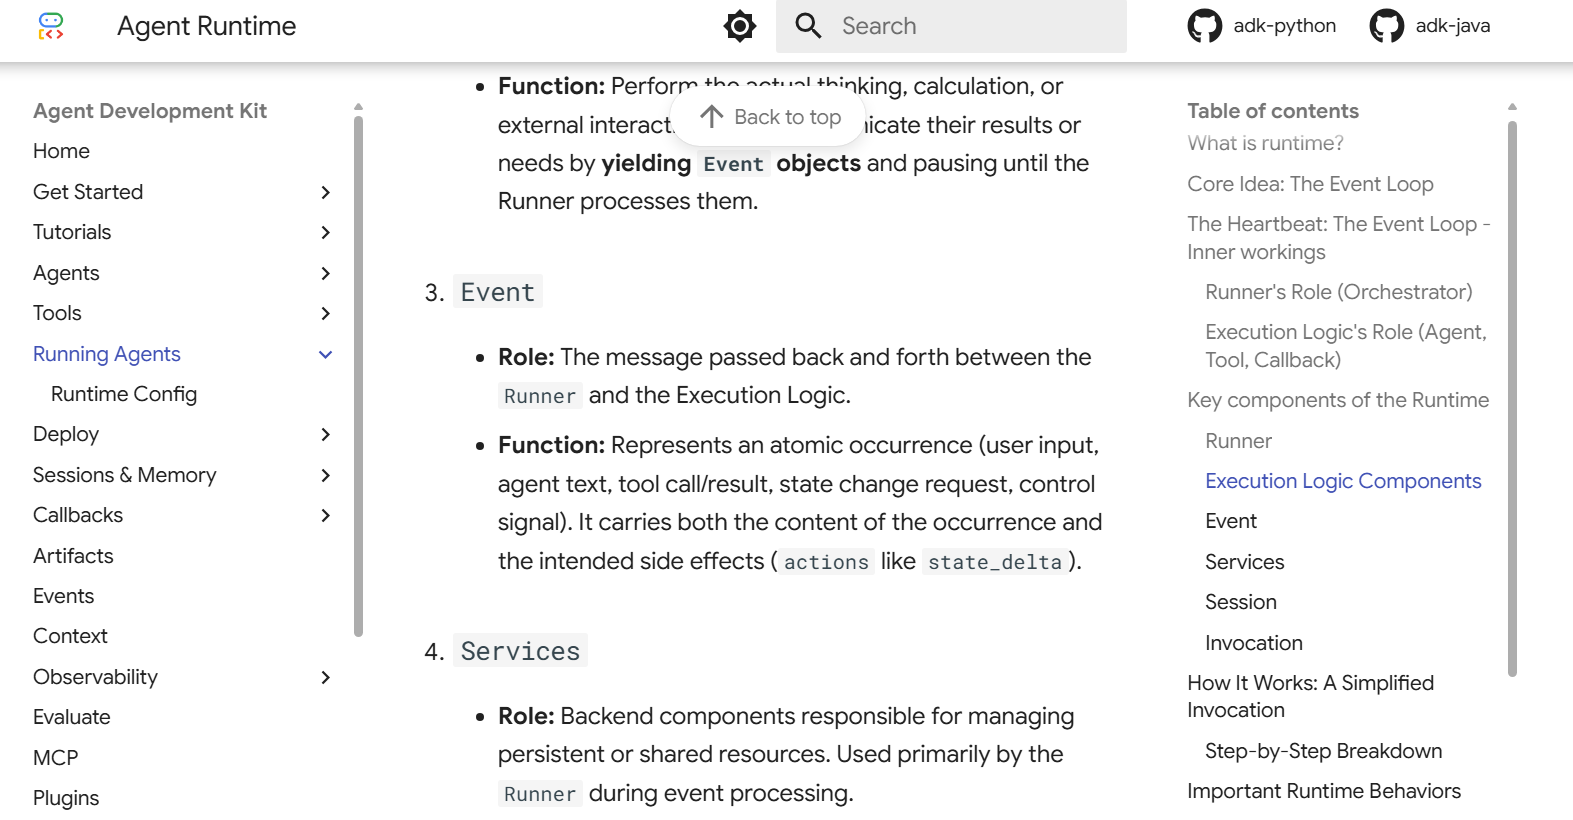 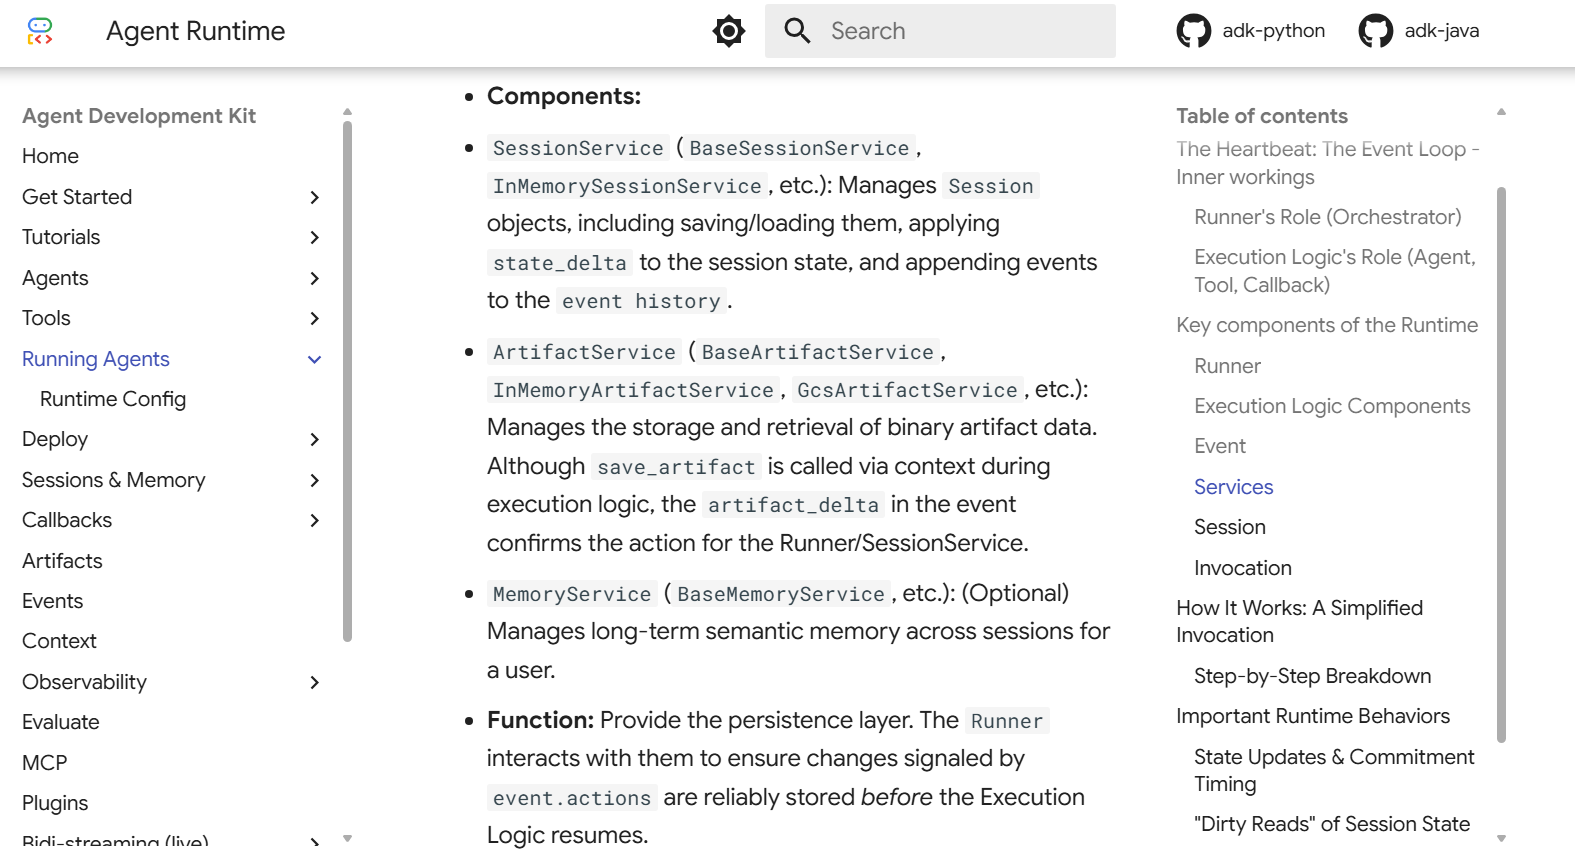 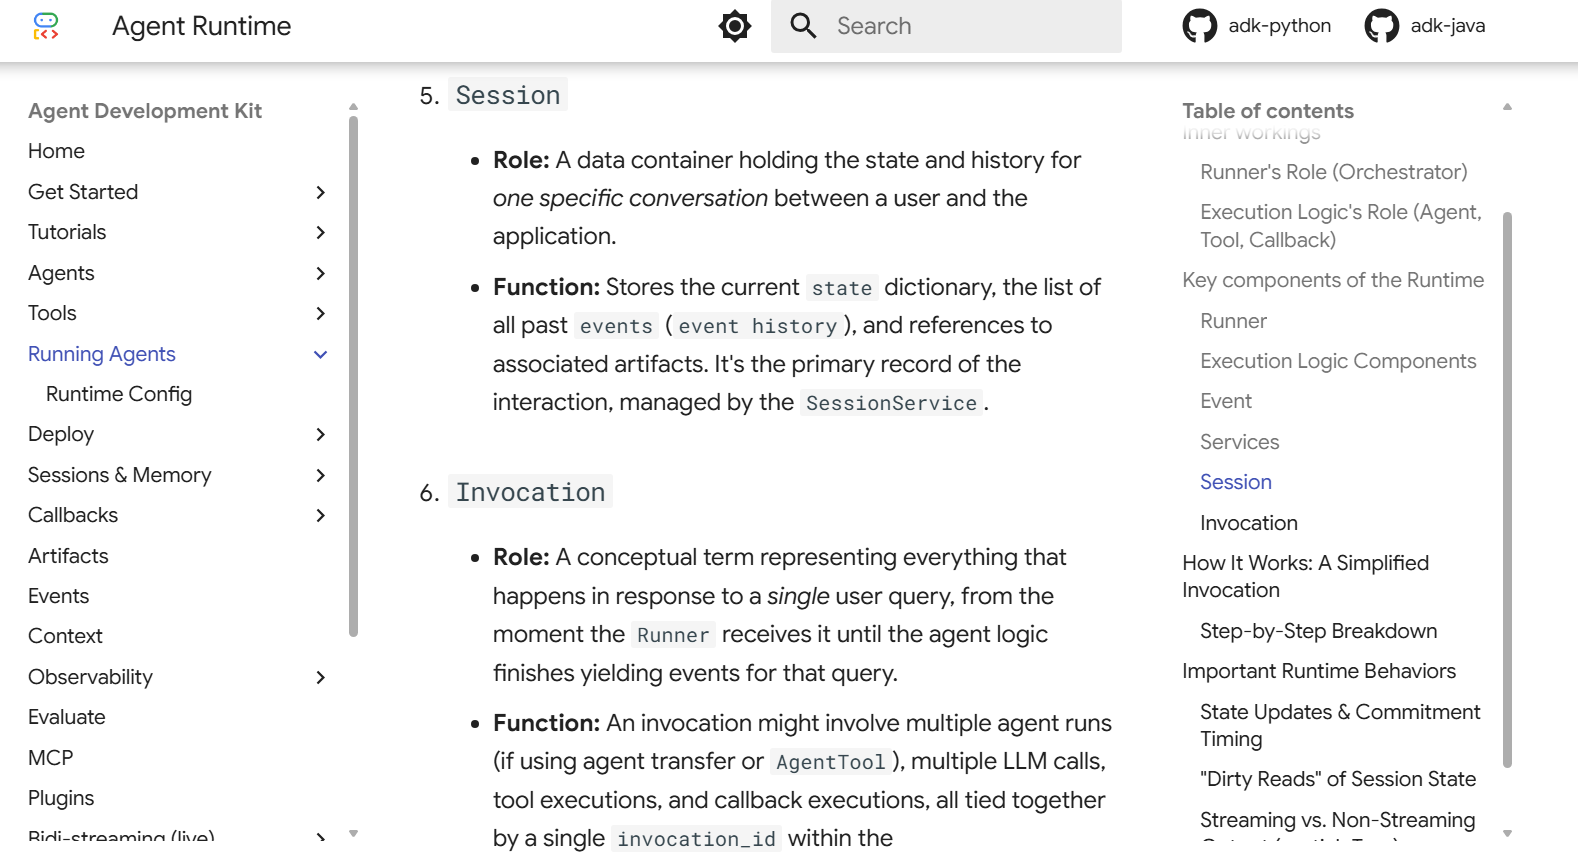 
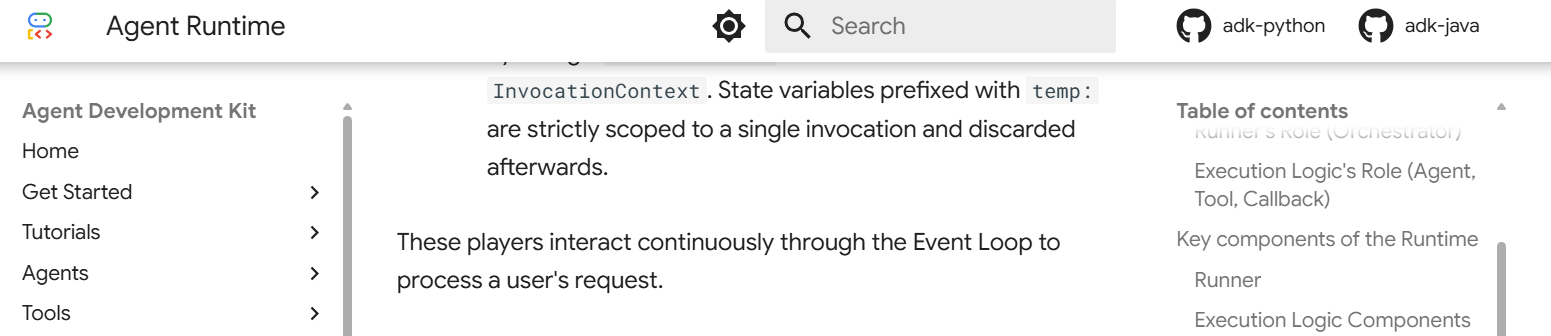

## How It Works: A Simplified Invocation
> Let's trace a simplified flow for a typical user query that involves an LLM agent calling a tool:

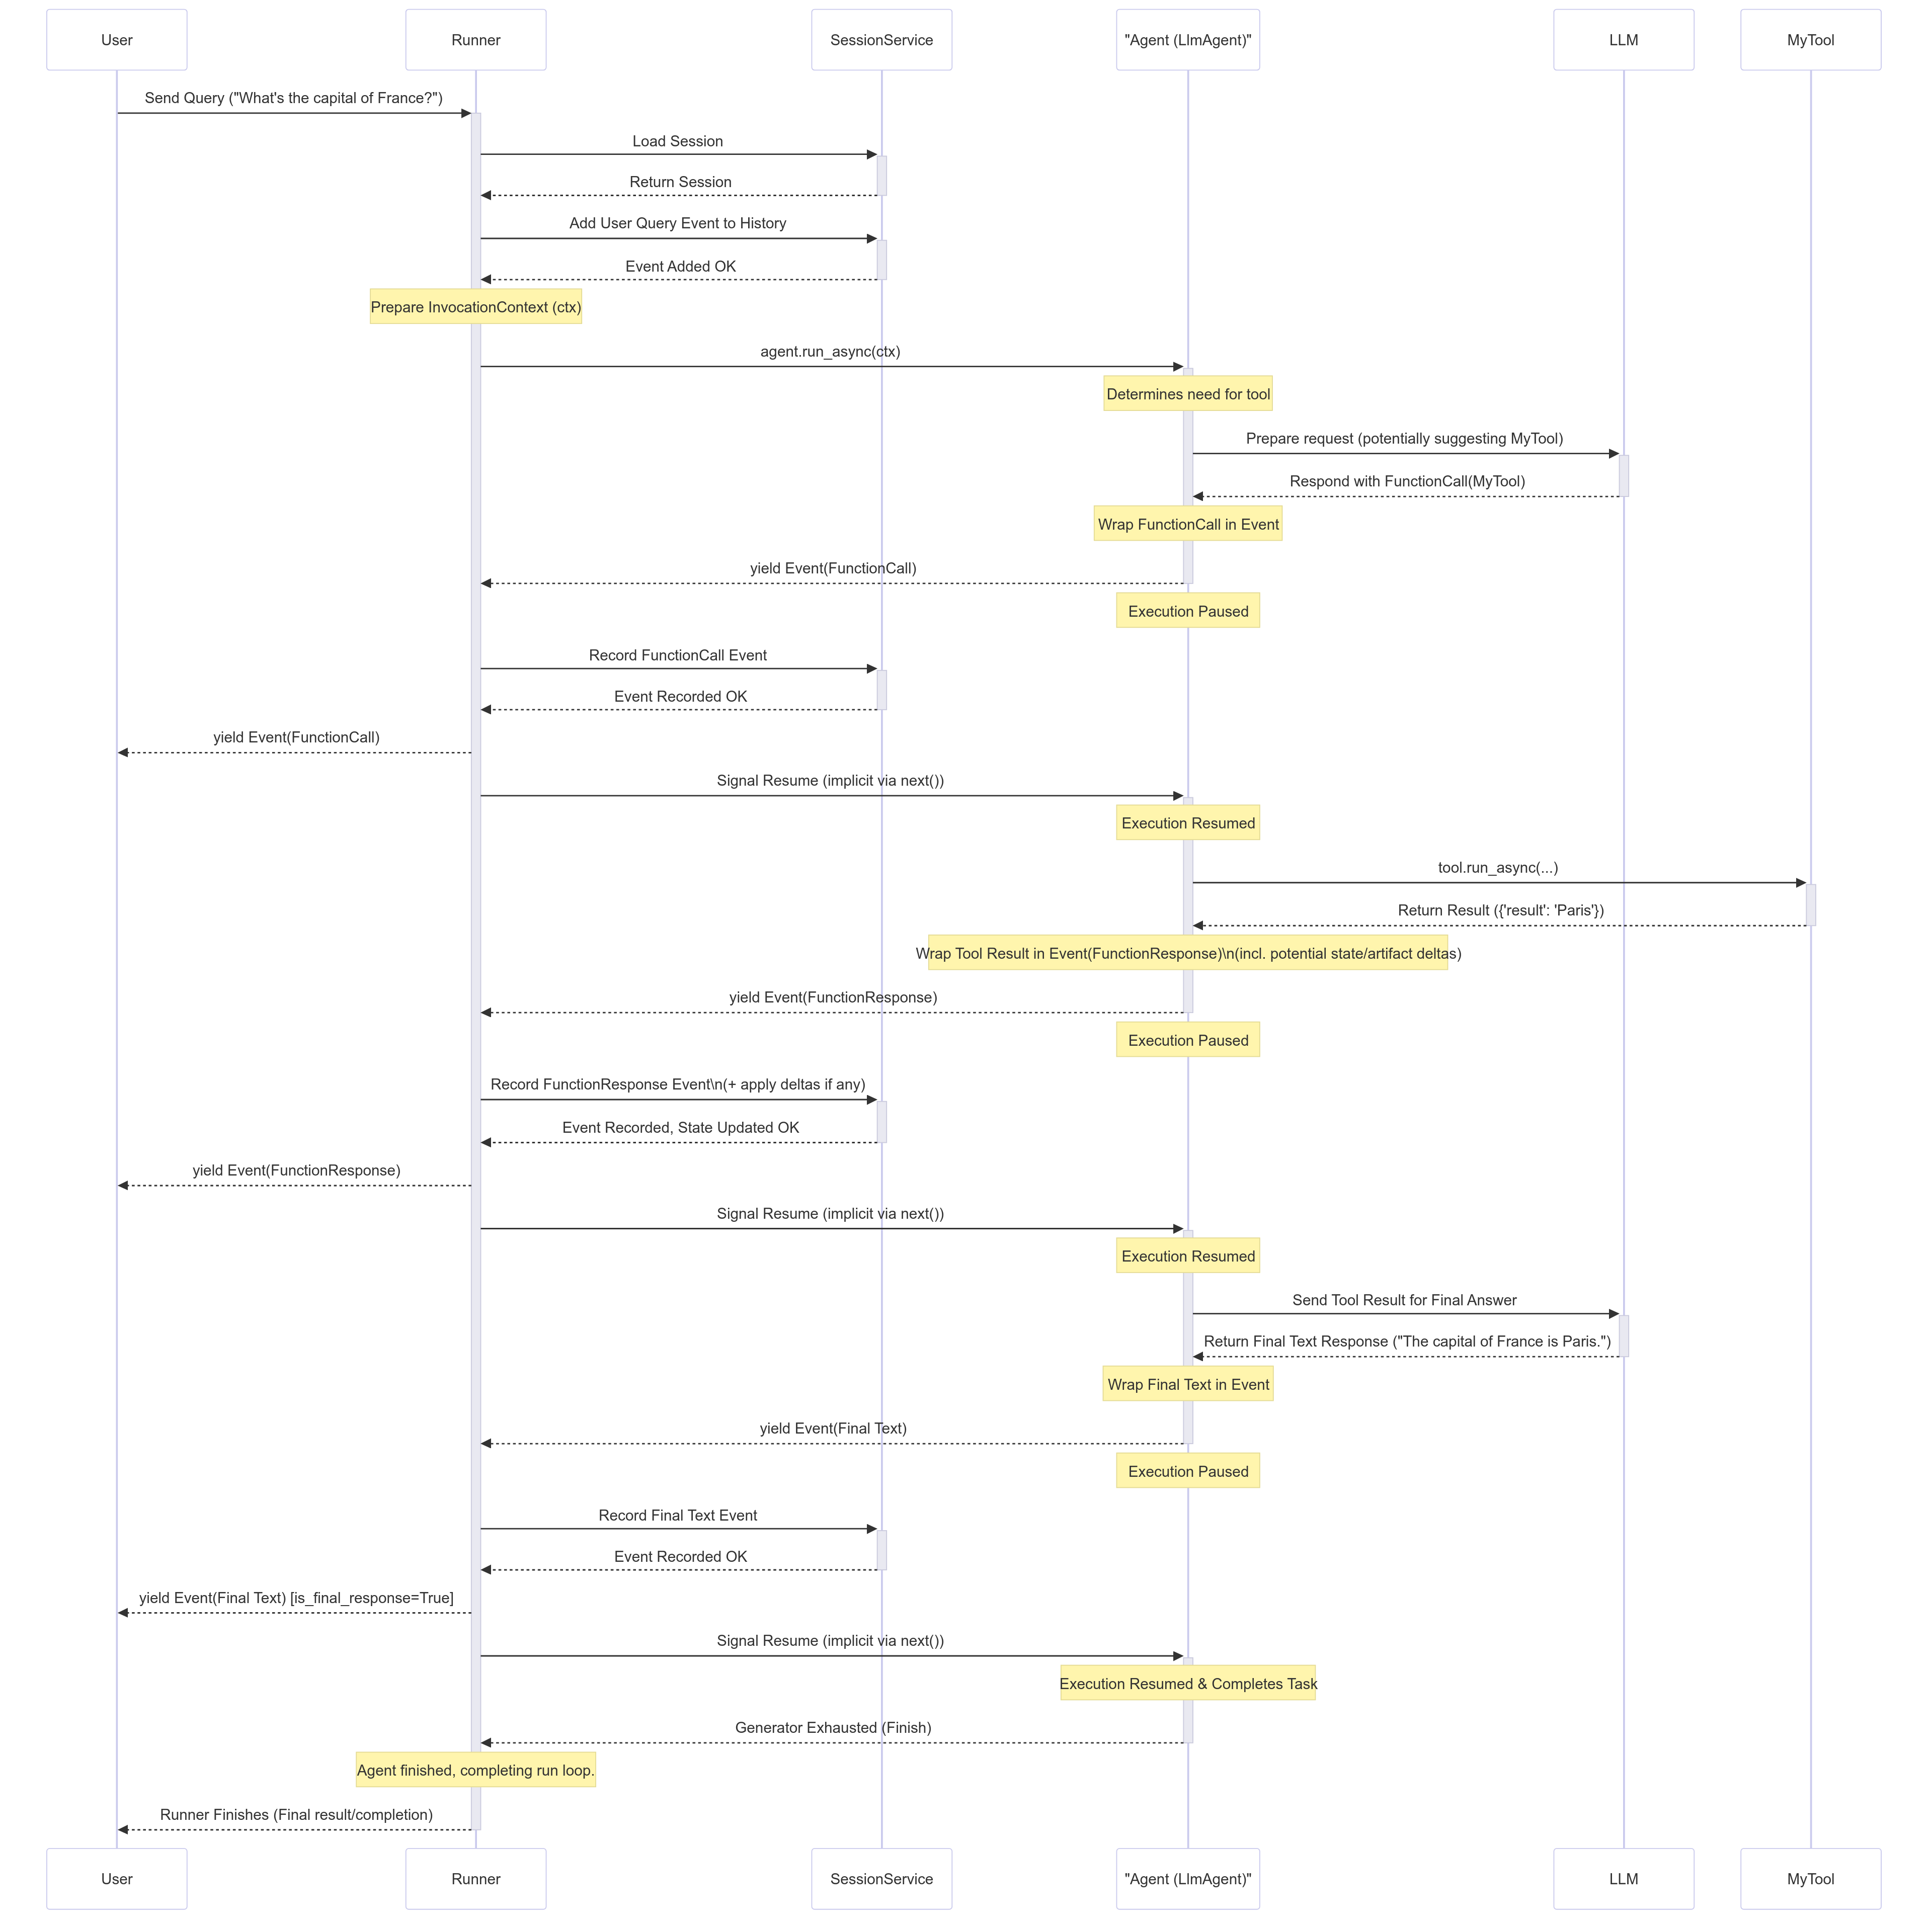

<br>

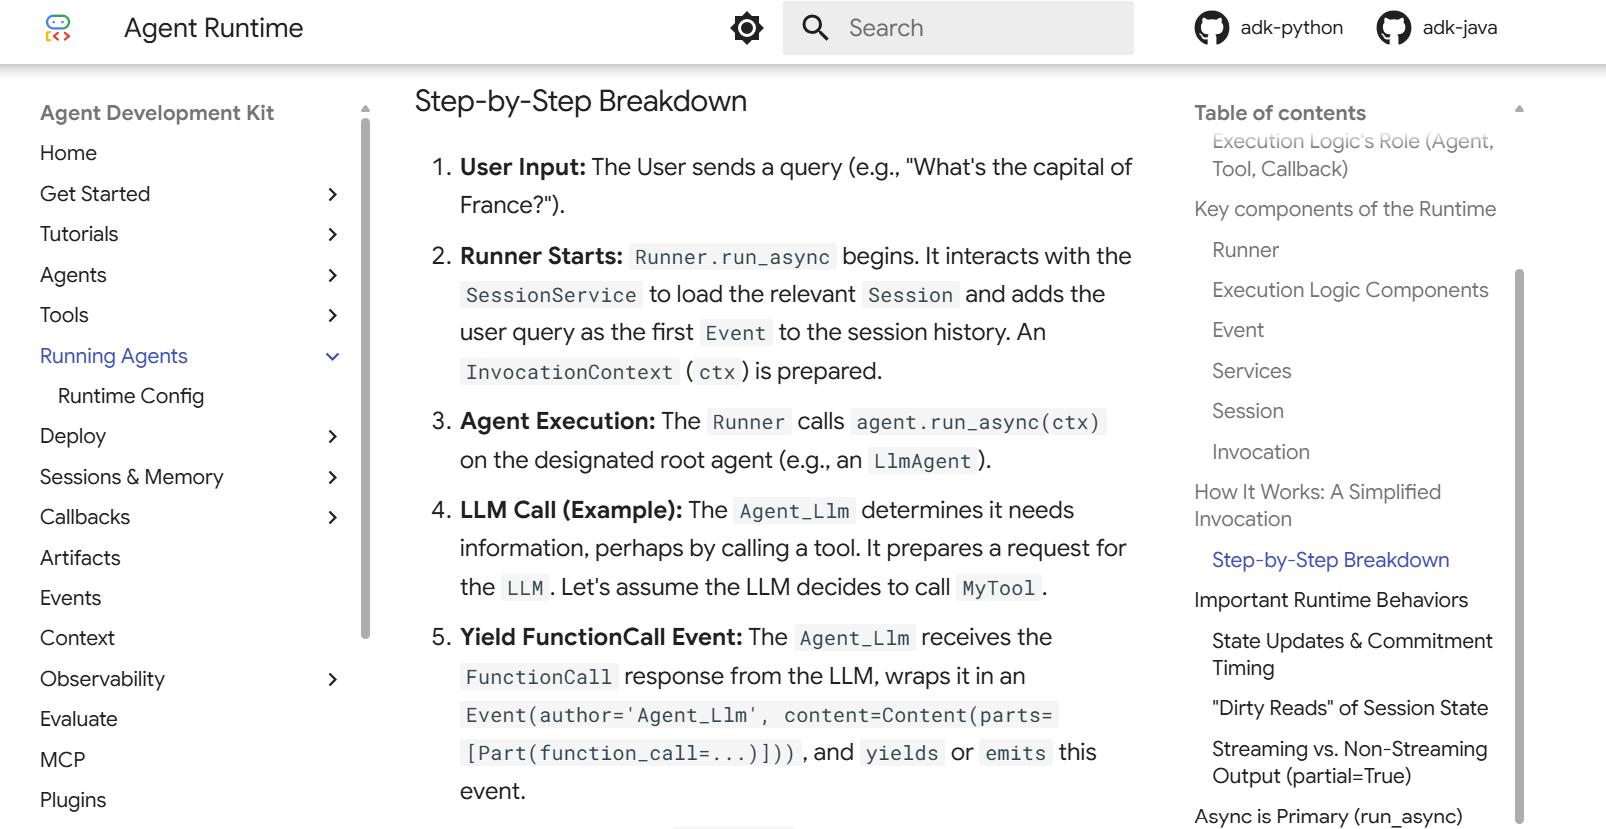 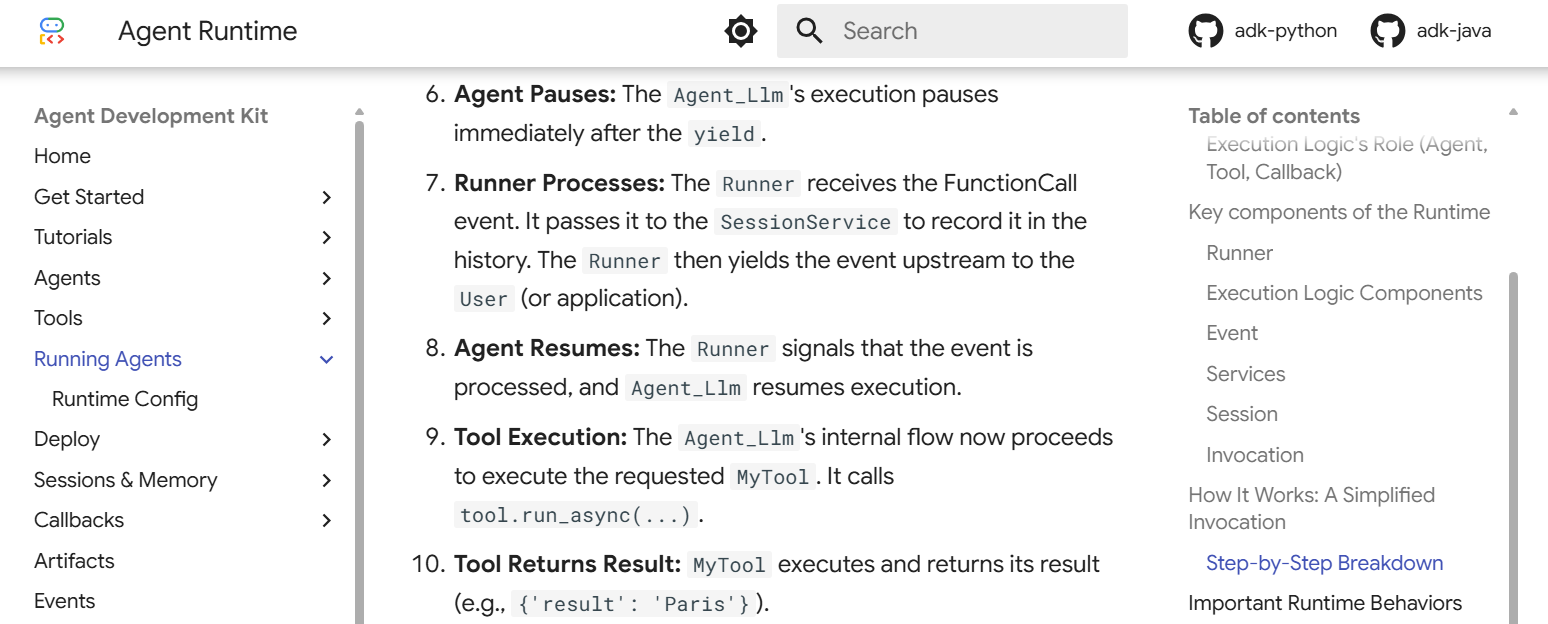 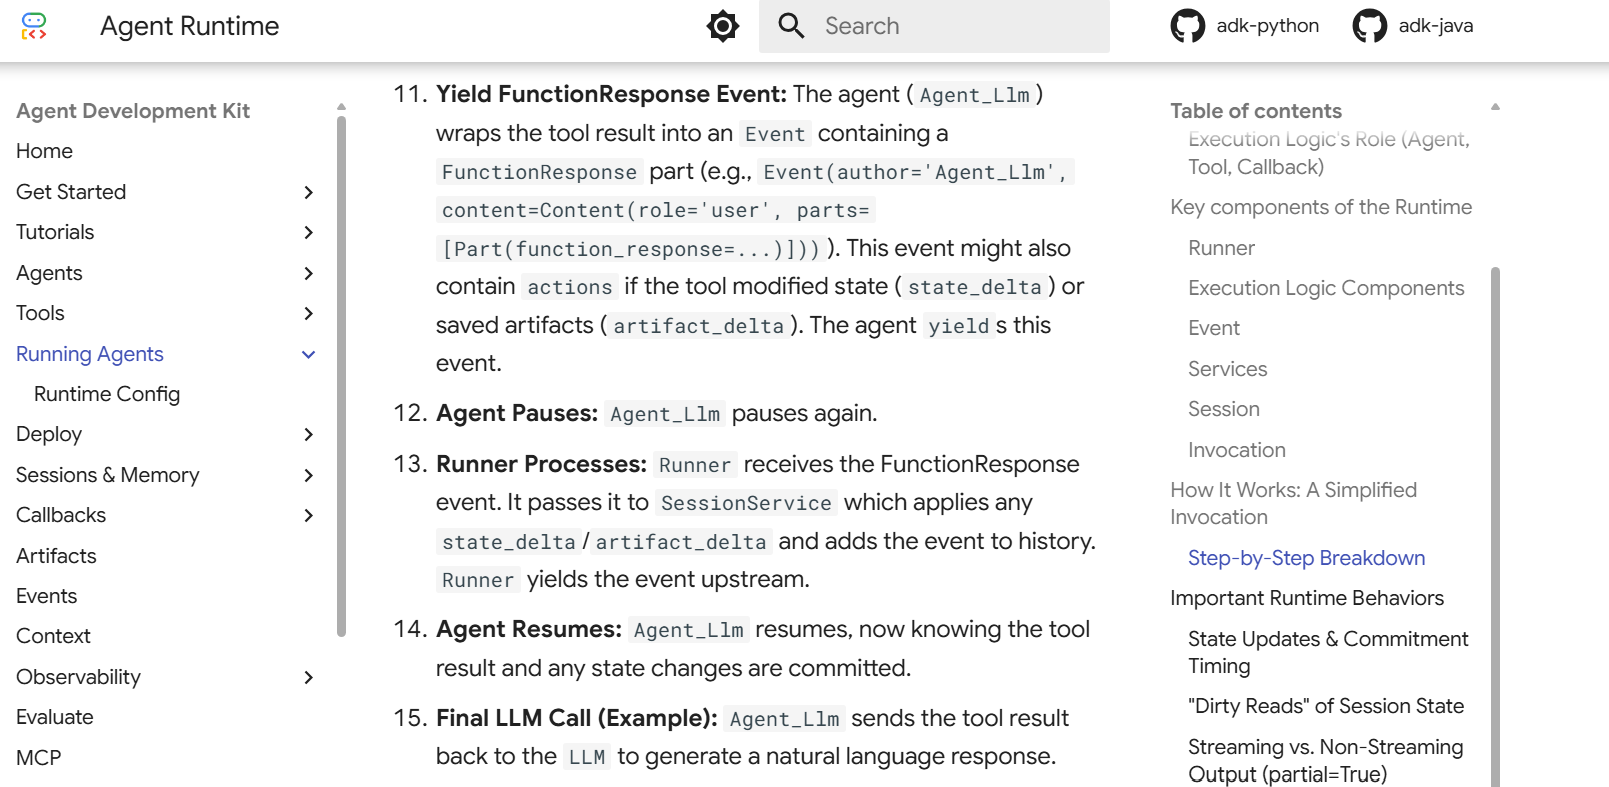 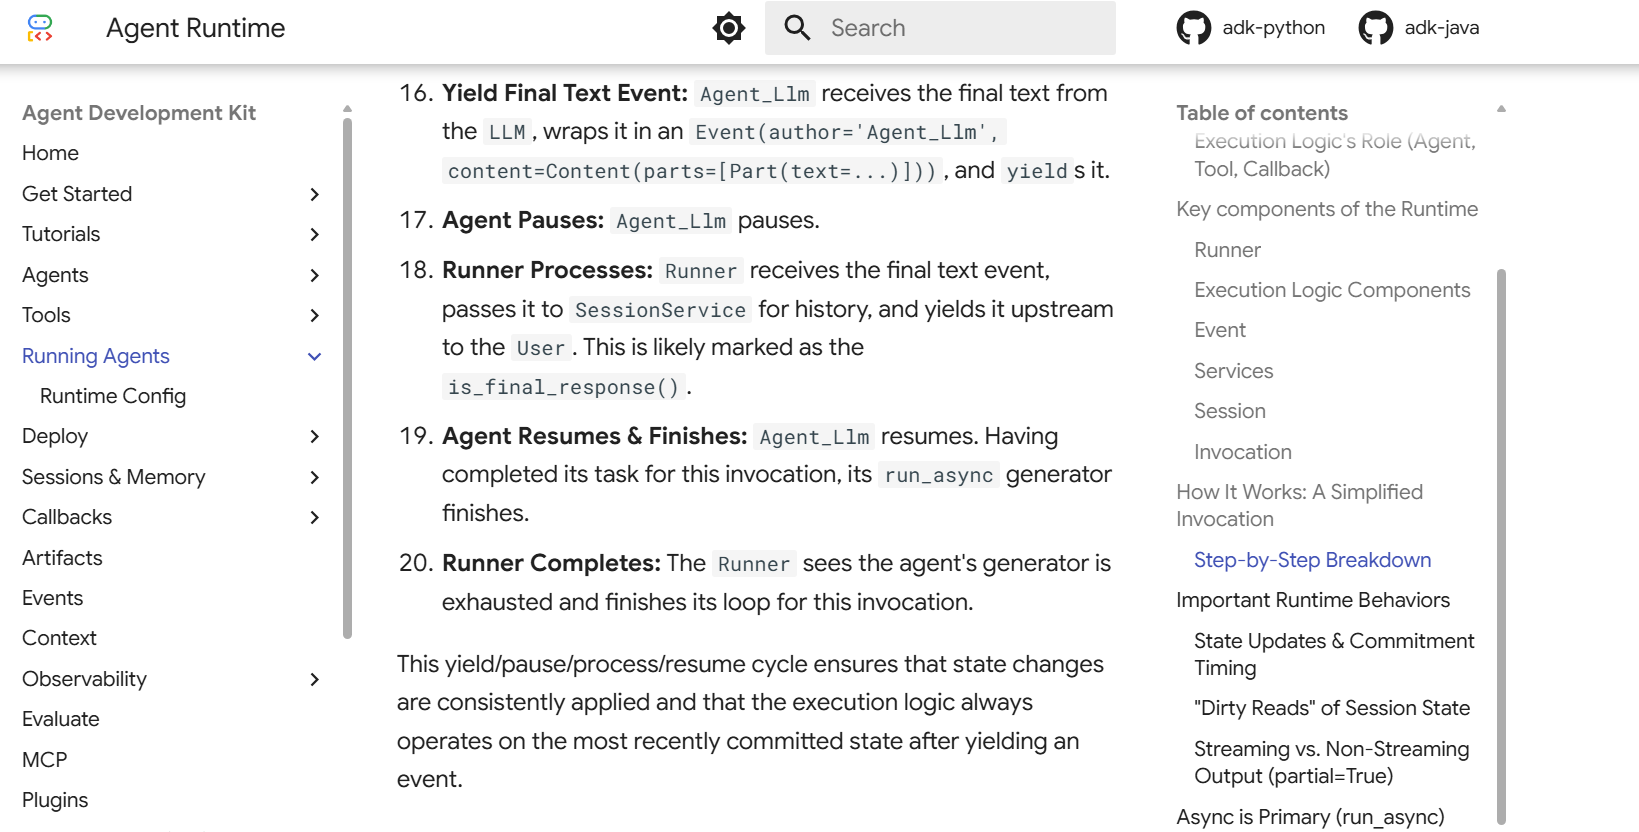

<br>

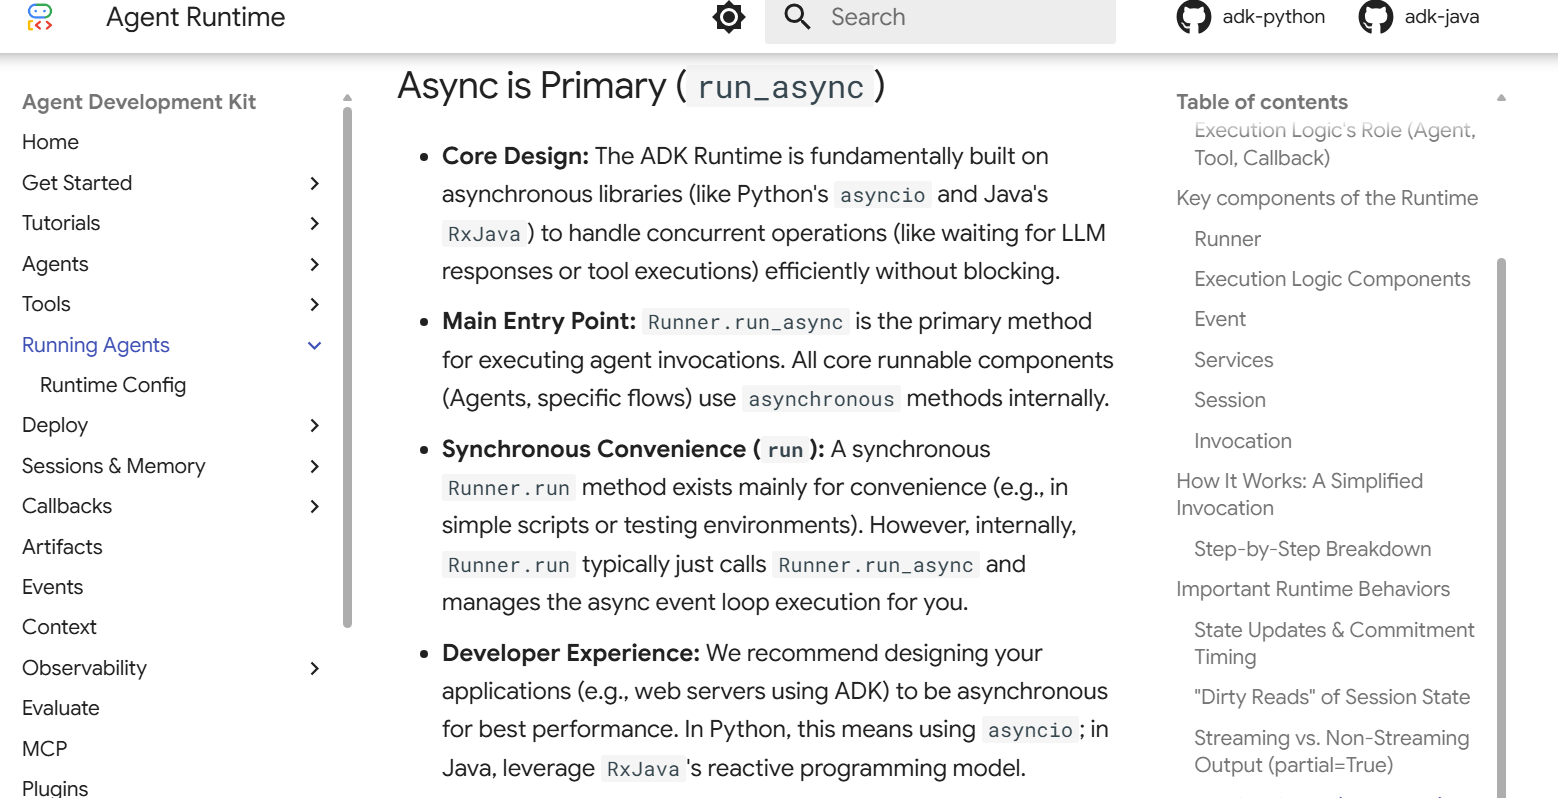 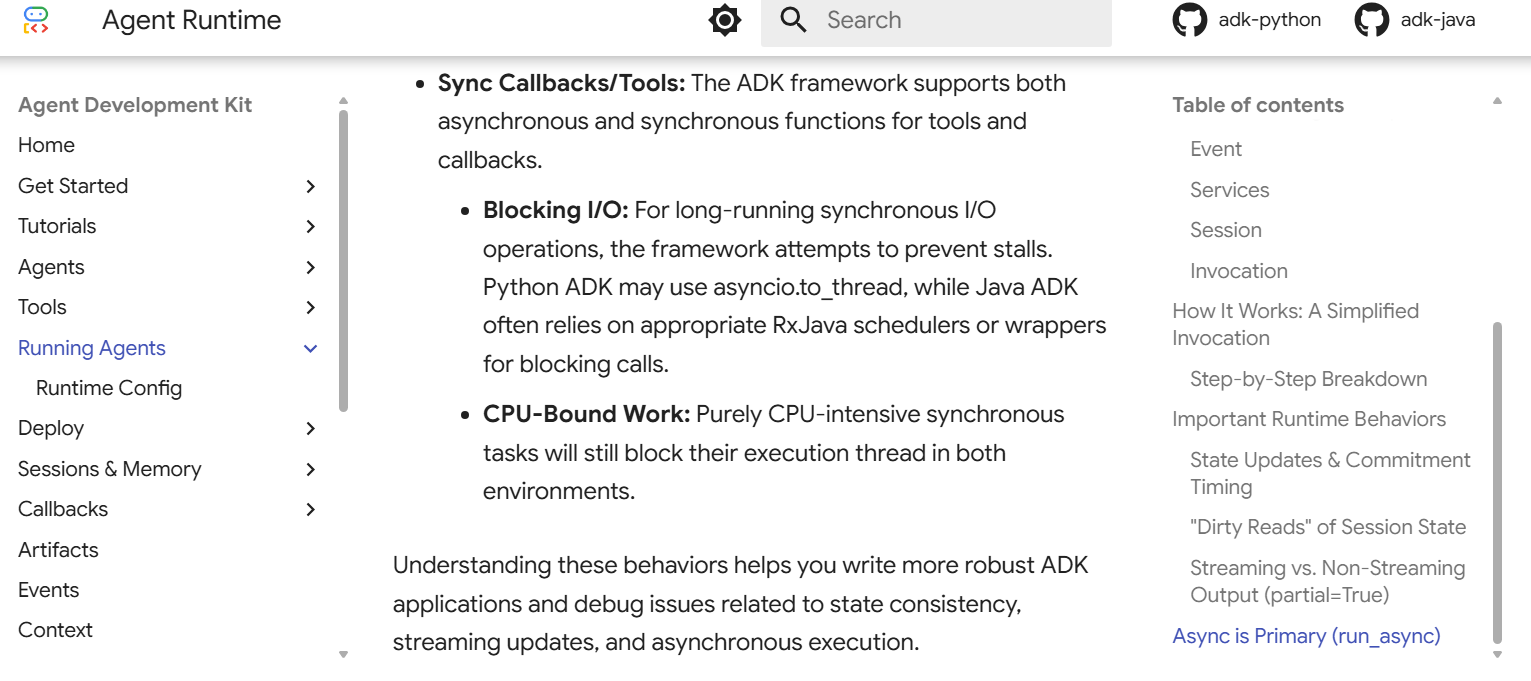
---

### `answer_agent`
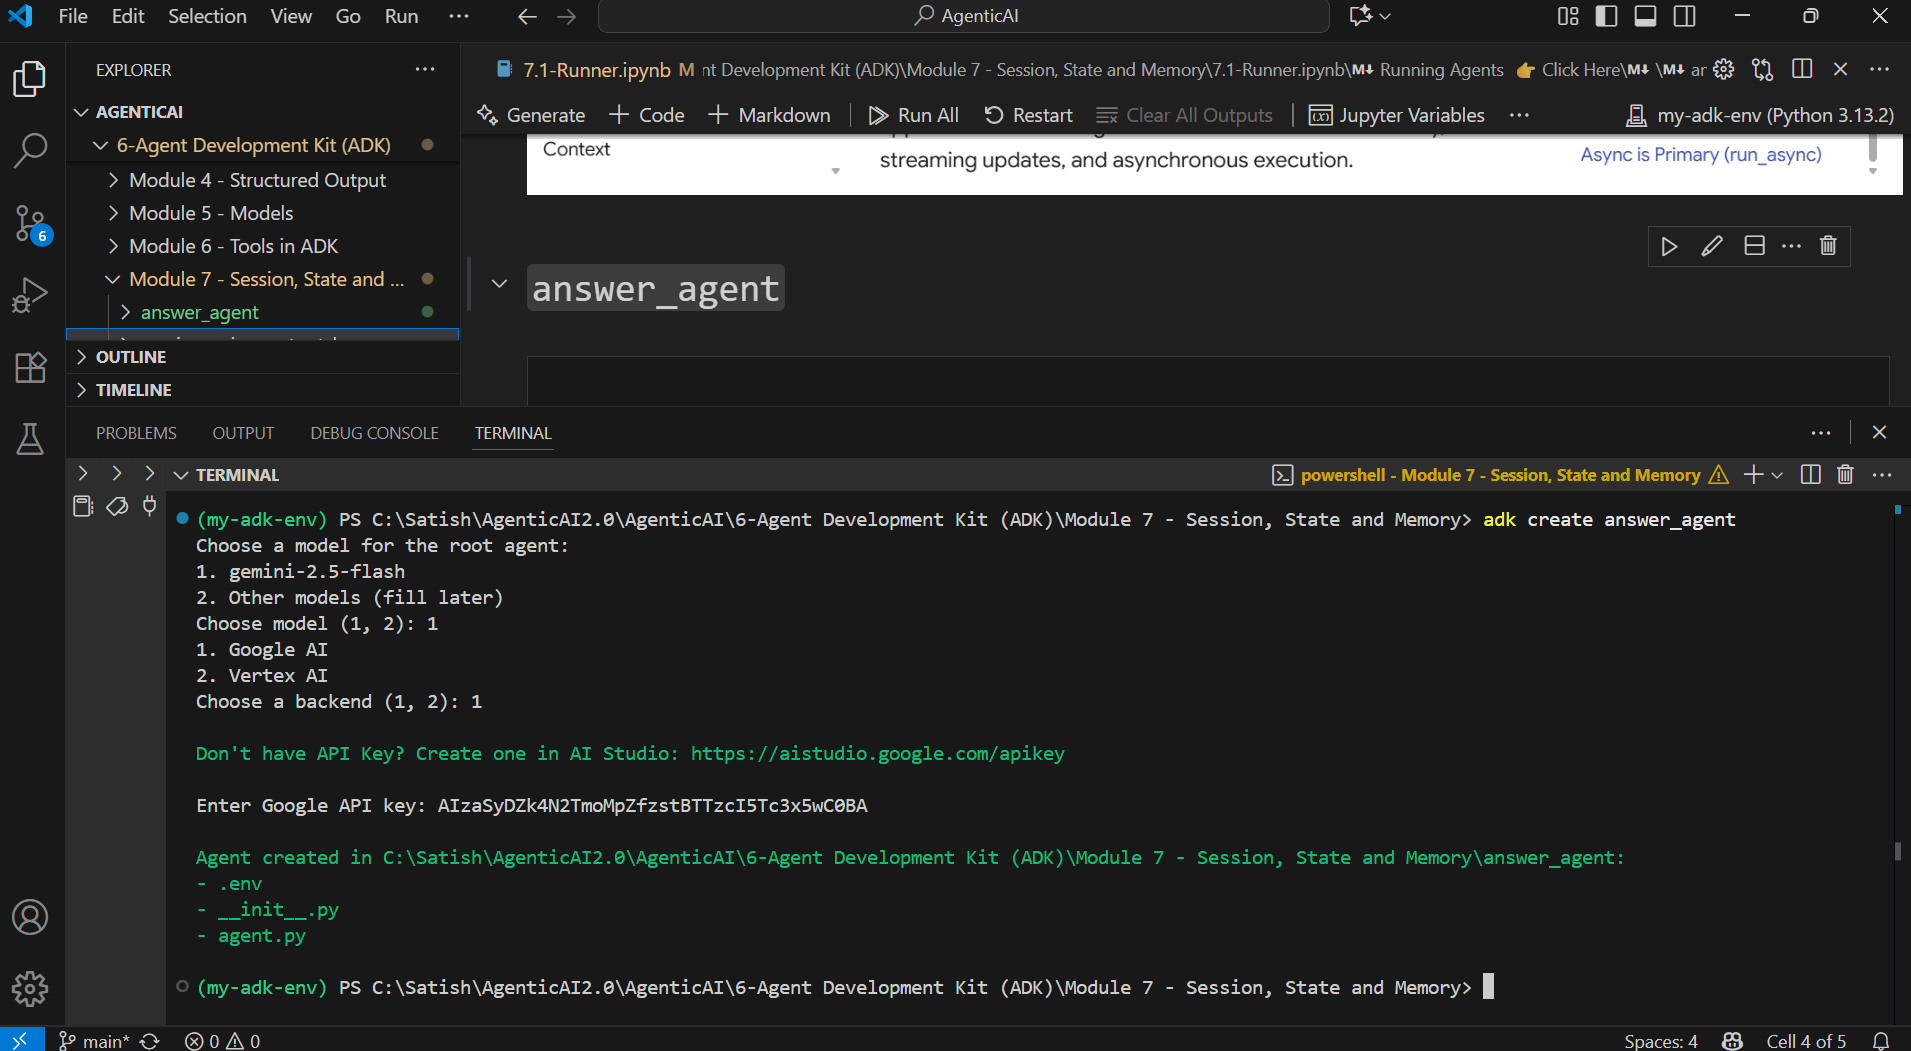 

----

`agent.py`
```Python
from google.adk.agents import Agent

from dotenv import load_dotenv
load_dotenv()

root_agent = Agent(
    model='gemini-2.0-flash-001',
    name='answer_agent',
    description='A helpful assistant for user questions.',
    instruction='''Answer user questions to the best of your knowledge
    You might have to answer questions about the user, their interests, and preferences.
    You can access the same for user {name} in the session state.

    and the data information is:
    {data}
    
    '''
)
```
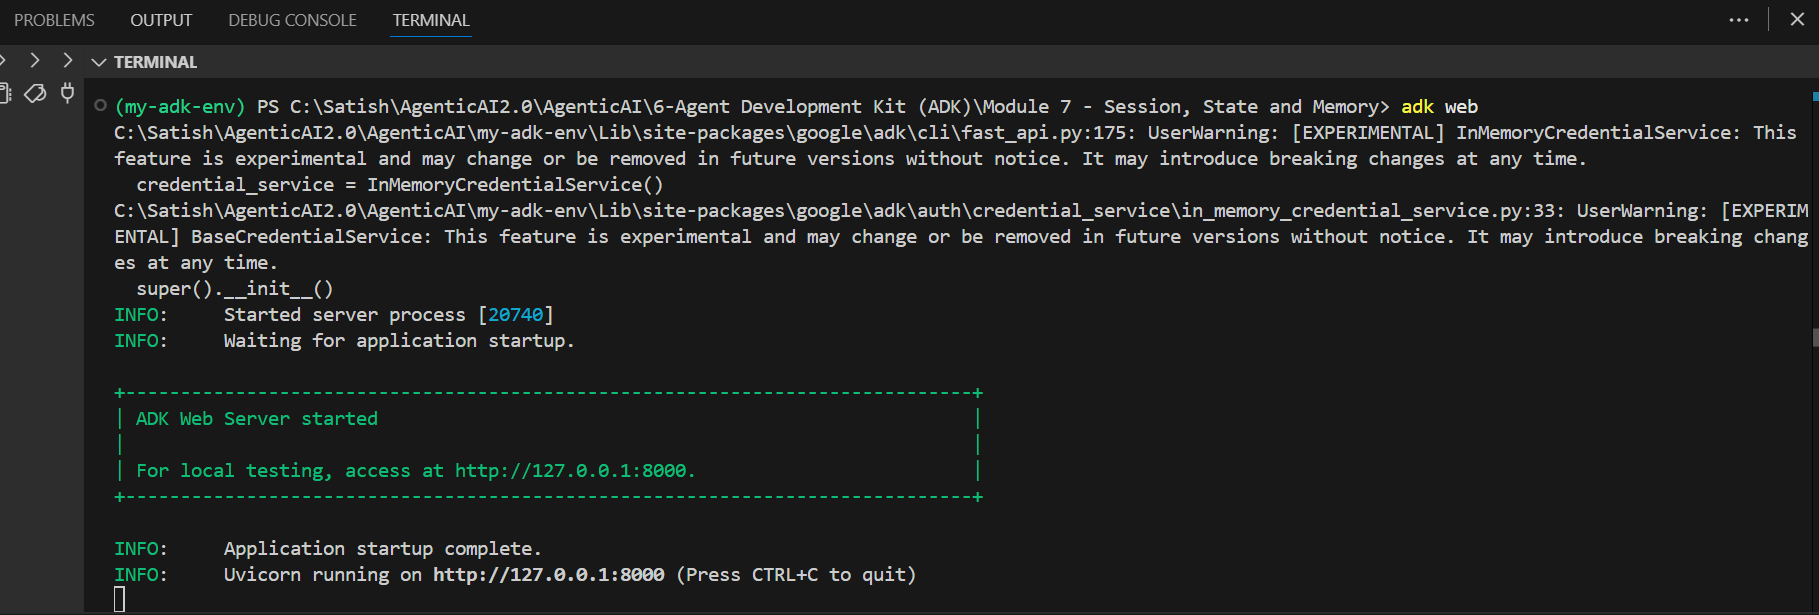 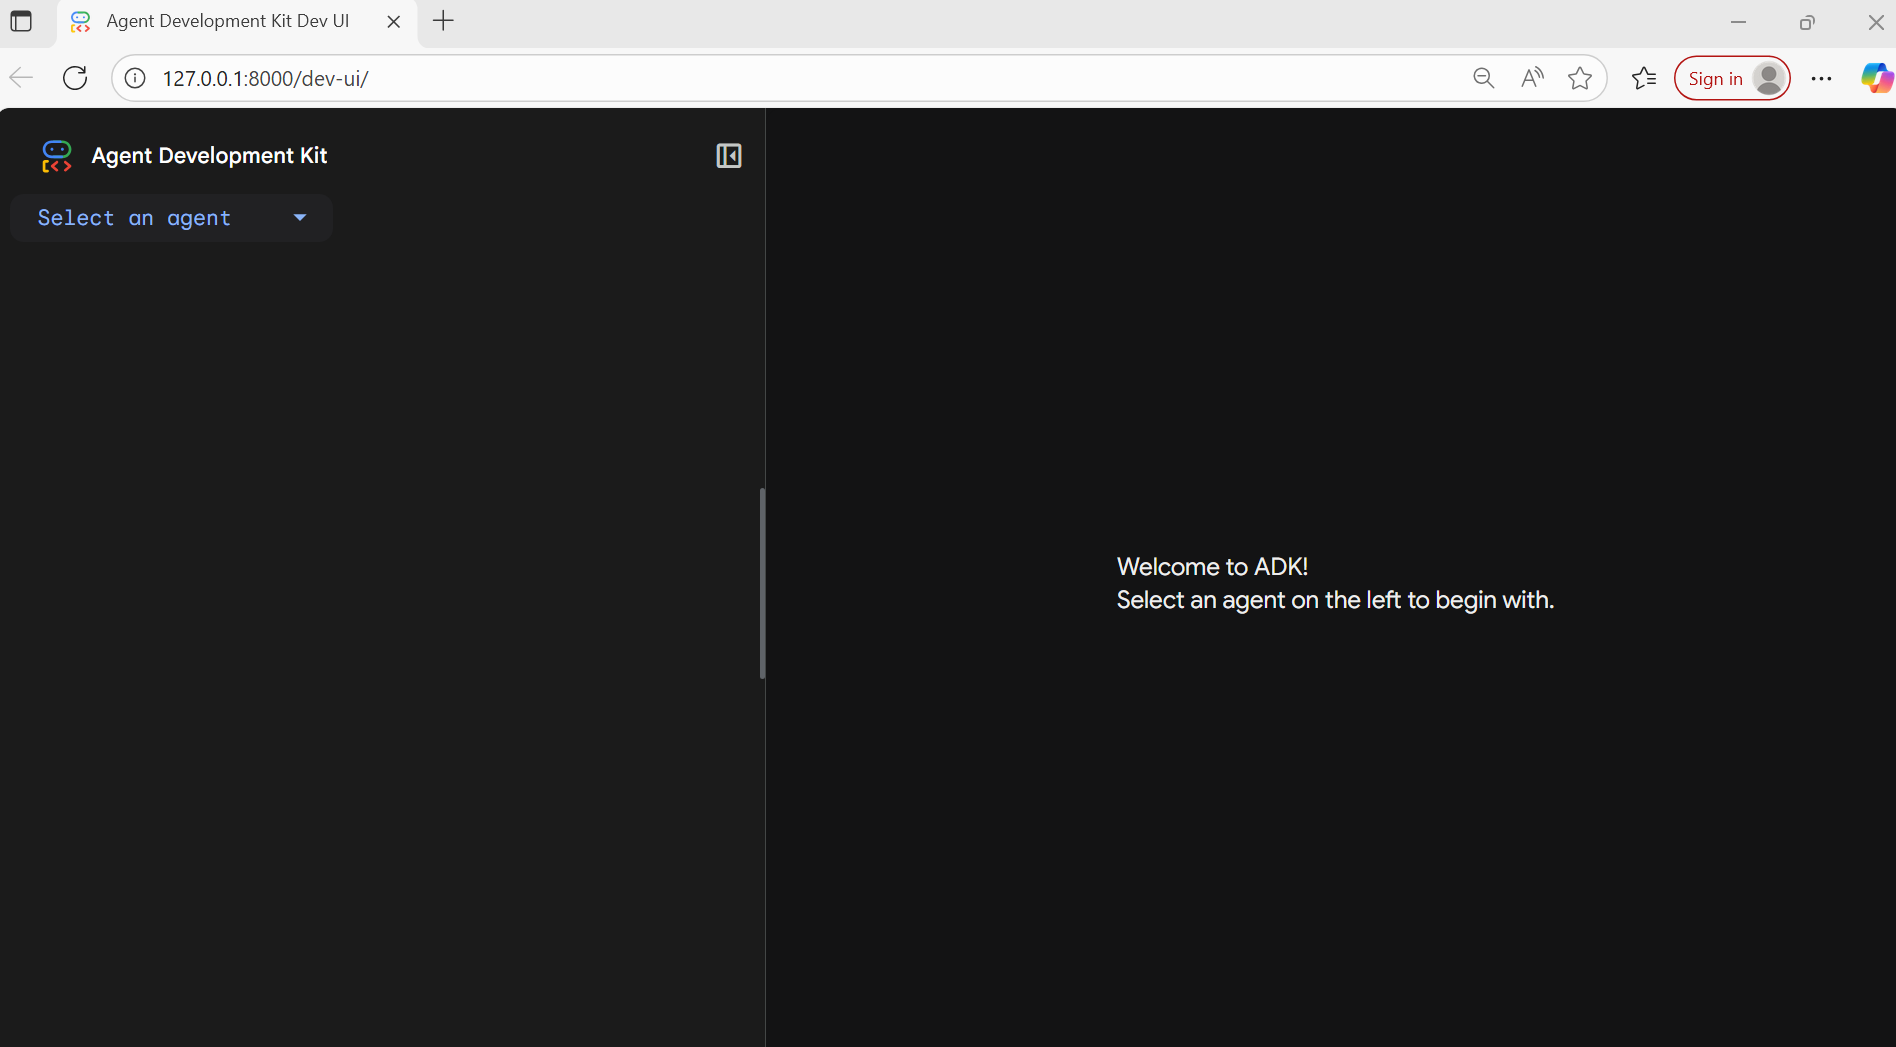 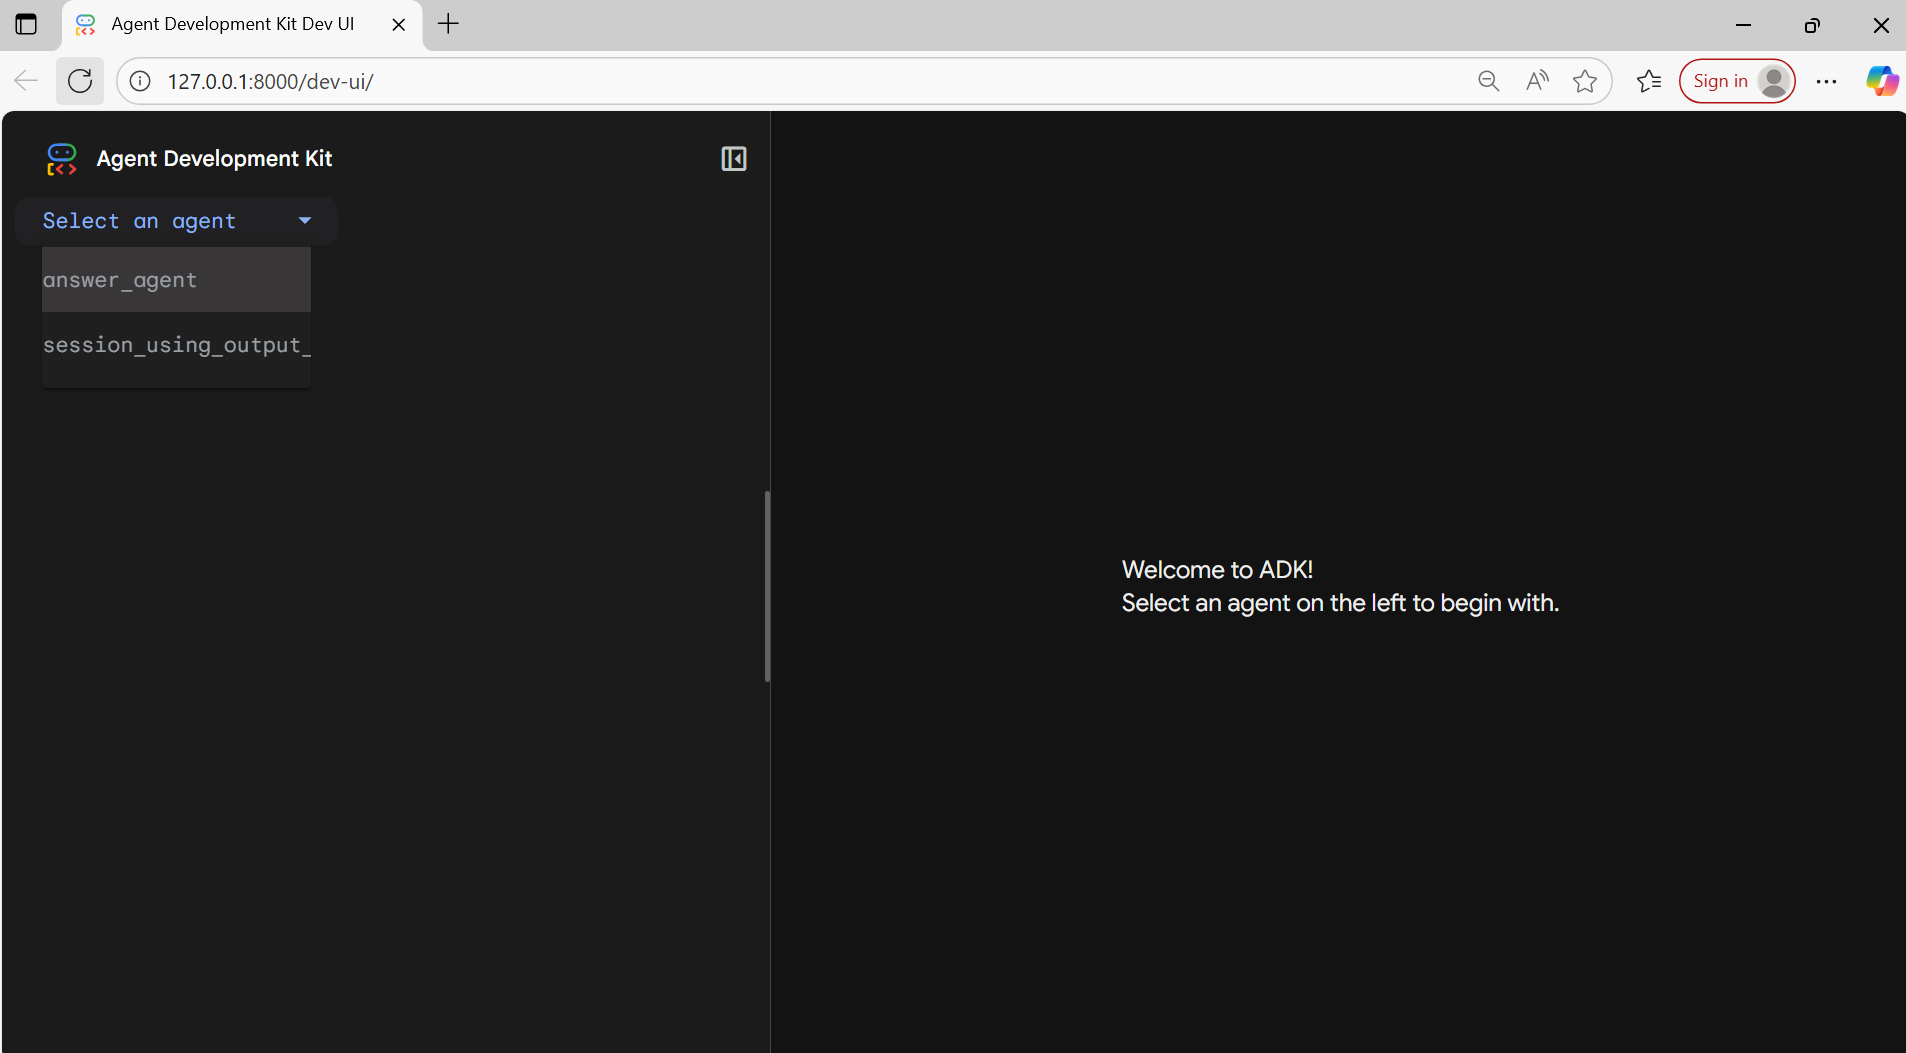 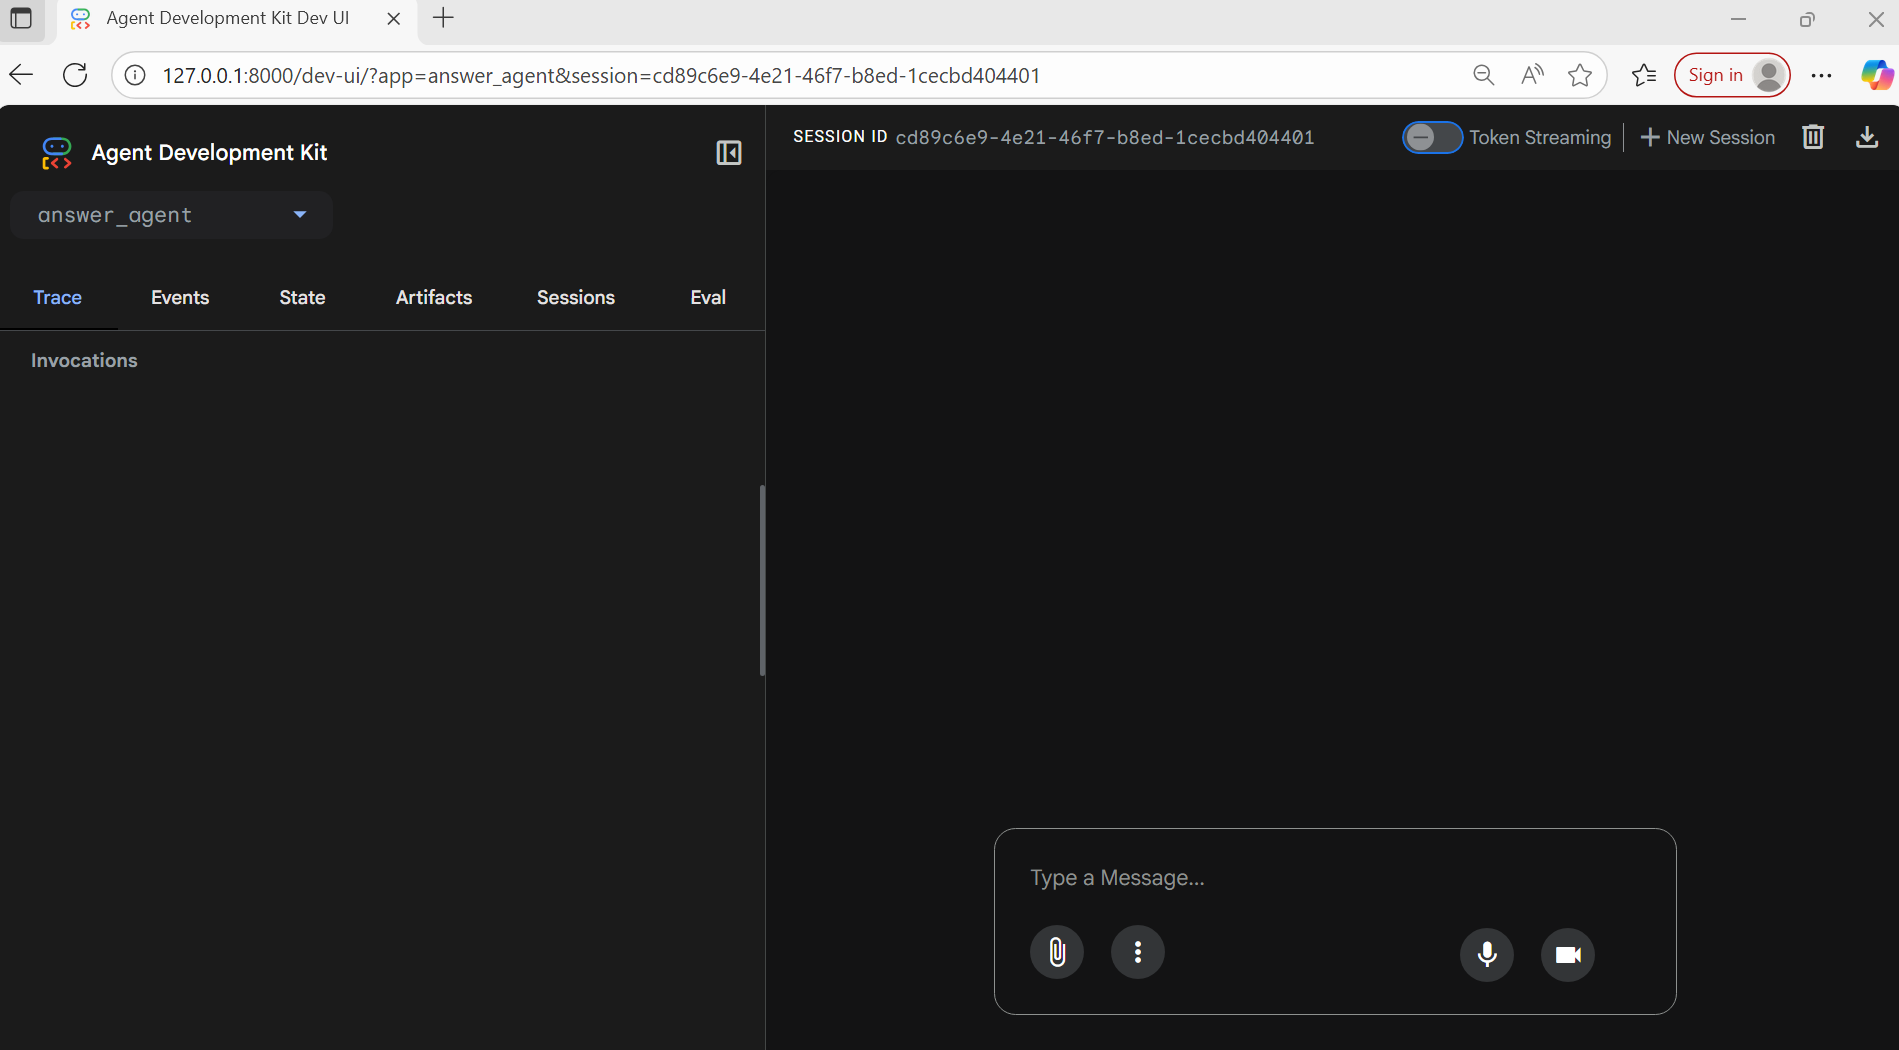 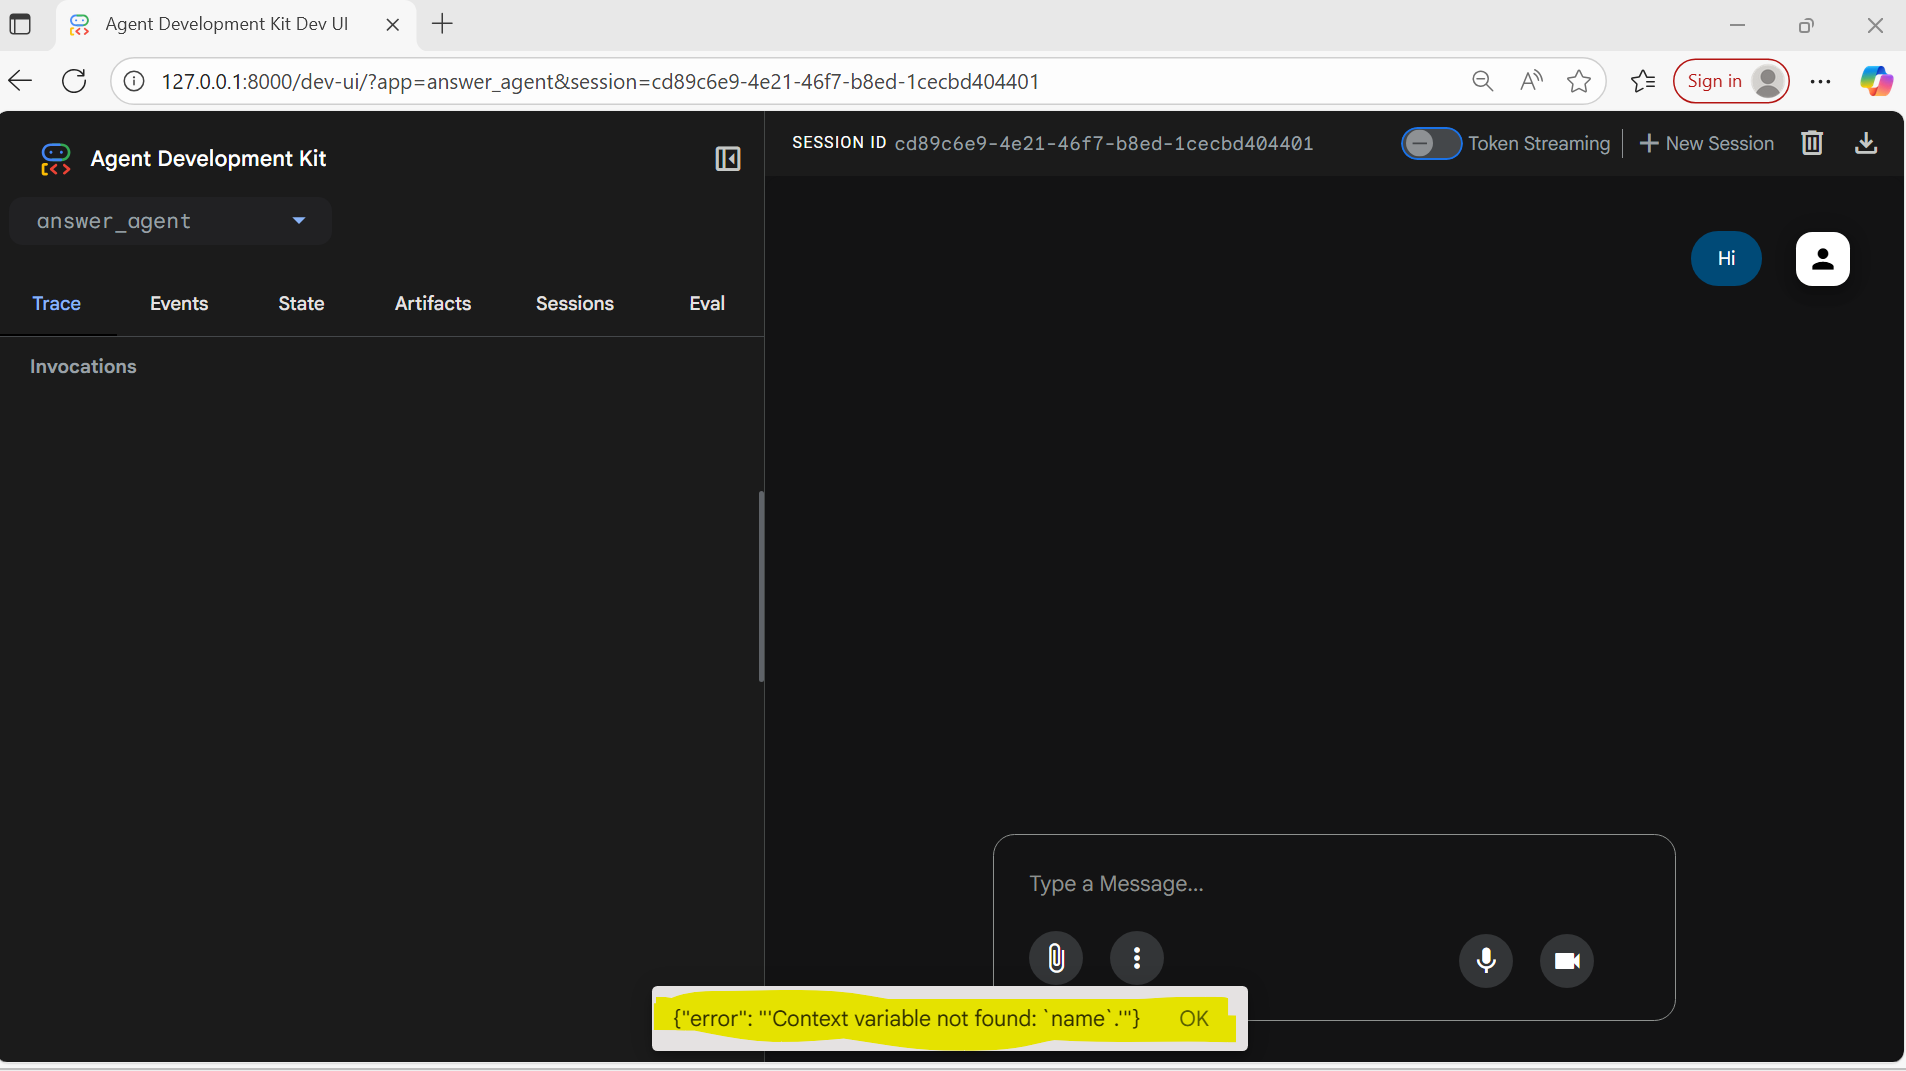

---

`Runner Practical.py`
```Python
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types
from agent import root_agent

import dotenv
dotenv.load_dotenv()

sessions_service_in_memory = InMemorySessionService()

initial_state = {
    "name": "Satish",
    "data":'''
    I am Satish, a software developer with 5 years of experience in full-stack development.
    I love Cricket, and my favourite player is Sachin Tendulkar
    '''
}

APP_NAME = "Answer Agent"
USER_ID = "satish"
SESSION_ID = 'satish_session'  # str(uuid.uuid4())  # Use a unique session ID in production


import asyncio

async def main():
    current_session = await sessions_service_in_memory.create_session(
        session_id=SESSION_ID,
        user_id=USER_ID,
        app_name=APP_NAME,
        state=initial_state
    )

    print(f"Session created with ID: {SESSION_ID}")

    created_sessions = await(sessions_service_in_memory.list_sessions(
        user_id=USER_ID,
        app_name=APP_NAME))
    print(f"Created sessions: {created_sessions}")

    runner = Runner(
        agent = root_agent,
        session_service = sessions_service_in_memory,
        app_name= APP_NAME
    )


    new_message = types.Content(
        role = 'user',
        parts = [types.Part(text='Which is the Favourite Player of User?')]
    )


    for event in runner.run(
        user_id=USER_ID,
        session_id=SESSION_ID,
        new_message=new_message,
    ):
        if event.is_final_response():
            if event.content and event.content.parts:
                print("Final response:", event.content.parts[0].text)



asyncio.run(main())

# print('Session state after interaction:')

# active_session= sessions_service_in_memory.get_session(
#     user_id=USER_ID,
#     session_id=SESSION_ID,
#     app_name=APP_NAME
# )
# print(active_session)

# for k,v in active_session.
#     print(f"{k}: {v}")
# # Note: The above code assumes that the agent.py file is in the same directory and contains the root_agent definition.
```

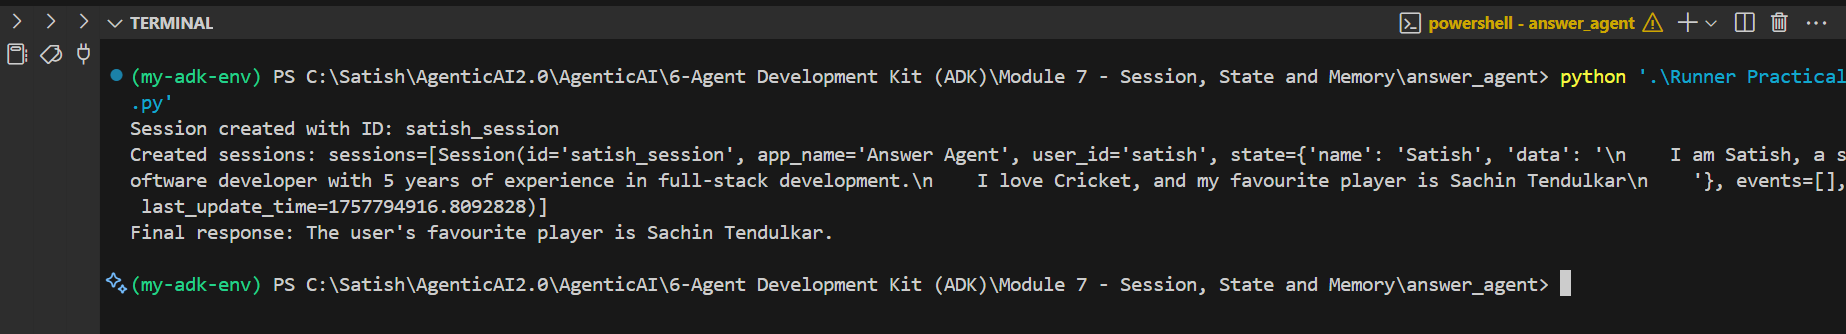

---